# Análisis global — Comparativa transversal entre sistemas

Este notebook genera las gráficas y tablas comparativas entre los seis
sistemas físicos para los ejes de análisis comunes. Los resultados
individuales de cada sistema se cargan desde sus respectivos JSONs y se
unifican en un DataFrame con una columna `sistema` que permite agrupar.

Ejes comunes analizados:
1. **Optimizador**: Adam vs Adam+L-BFGS
2. **Learning rate**: 0.001 vs 0.01
3. **Pesos dinámicos**: fijos vs activados
4. **Sampler**: LHS vs grid
5. **Arquitectura**: base vs ampliada

In [46]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.family":         "serif",
    "font.size":           12,
    "axes.linewidth":      1.2,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          150,
})

RESULTS_DIR = Path("results")
FIGS_DIR    = Path("figures_analysis_global")
FIGS_DIR.mkdir(exist_ok=True)

C_PINN = "#1f4e96"
C_NN   = "#e07b39"
C_CN   = "#888888"

In [2]:
# ── Carga de cada sistema ─────────────────────────────────────────────────

def load_oscilador_clasico():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("oscilador_clasico/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "Osc. clásico",
            "seed":                cfg["seed"],
            "lr":                  cfg["lr"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "num_domain_points":   cfg["num_domain_points"],
            "num_train_points":    cfg["num_train_points"],
            "train_region":        cfg["train_region"],
            "error_l2_pinn":       res["pinn"]["error_L2"],
            "error_l2_nn":         res["nn"]["error_L2"],
        })
    return records

def load_pozo():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("pozo_infinito/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "Pozo",
            "seed":                cfg["seed"],
            "estado_n":            cfg["estado_n"],
            "lr":                  cfg["lr"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "use_data":            cfg["use_data"],
            "use_orthogonality":   cfg["use_orthogonality"],
            "num_domain_points":   cfg["num_domain_points"],
            "num_train_points":    cfg["num_train_points"],
            "train_region":        cfg["train_region"],
            "error_l2_pinn":       res["pinn"]["error_L2"],
            "error_l2_nn":         res["nn"]["error_L2"],
        })
    return records

def load_qho():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("qho/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "QHO",
            "seed":                cfg["seed"],
            "estado_n":            cfg["estado_n"],
            "lr":                  cfg["lr"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "use_data":            cfg["use_data"],
            "use_orthogonality":   cfg["use_orthogonality"],
            "num_domain_points":   cfg["num_domain_points"],
            "num_train_points":    cfg["num_train_points"],
            "train_region":        cfg["train_region"],
            "error_l2_pinn":       res["pinn"]["error_L2"],
            "error_l2_nn":         res["nn"]["error_L2"],
        })
    return records

def load_pendulo():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("pendulo_inverso/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "Péndulo",
            "seed":                cfg["seed"],
            "lr":                  cfg["lr"],
            "noise_std":           cfg["noise_std"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "num_domain_points":   cfg["num_domain_points"],
            "num_train_points":    cfg["num_train_points"],
            "train_region":        cfg["train_region"],
            "error_l2_pinn":       res["pinn"]["error_L2"],
            "error_l2_nn":         res["nn"]["error_L2"],
        })
    return records

def load_calor():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("heat_inverse/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "Calor",
            "seed":                cfg["seed"],
            "lr":                  cfg["lr"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "num_collocation":     cfg["num_collocation"],
            "num_train_points":    cfg["num_train_points"],
            "noise_std":           cfg["noise_std"],
            "warmup_epochs":       cfg["warmup_epochs"],
            "alpha_true":          cfg["alpha_true"],
            "alpha_init":          cfg["alpha_init"],
            "error_l2_pinn":       res["pinn"]["error_L2_mean"],
            "error_l2_nn":         res["nn"]["error_L2_mean"],
        })
    return records

def load_tunnel():
    records = []
    for fpath in sorted(RESULTS_DIR.glob("tunnel/**/*.json")):
        with open(fpath) as f:
            d = json.load(f)
        cfg, res = d["config"], d["resultados_finales"]
        records.append({
            "sistema":             "Túnel",
            "seed":                cfg["seed"],
            "lr":                  cfg["lr"],
            "sampler":             cfg["sampler"],
            "use_dynamic_weights": cfg["use_dynamic_weights"],
            "use_data_pinn":       cfg["use_data_pinn"],
            "optimizer":           cfg["optimizer"],
            "hidden_layers":       str(cfg["hidden_layers"]),
            "num_collocation":     cfg["num_collocation"],
            "num_train_points":    cfg["num_train_points"],
            "warmup_epochs":       cfg["warmup_epochs"],
            "V0":                  cfg["V0"],
            "error_l2_pinn":       res["pinn"]["error_L2_mean"],
            "error_l2_nn":         res["nn"]["error_L2_mean"],
        })
    return records

# ── Unificar ──────────────────────────────────────────────────────────────
all_records = (
    load_oscilador_clasico() +
    load_pozo() +
    load_qho() +
    load_pendulo() +
    load_calor() +
    load_tunnel()
)

df_all = pd.DataFrame(all_records)
print(f"Total experimentos cargados: {len(df_all)}")
print(f"Sistemas: {df_all['sistema'].unique()}")
for s, grp in df_all.groupby("sistema"):
    print(f"  {s}: {len(grp)}")

Total experimentos cargados: 1280
Sistemas: ['Osc. clásico' 'Pozo' 'QHO' 'Péndulo' 'Calor' 'Túnel']
  Calor: 220
  Osc. clásico: 190
  Pozo: 230
  Péndulo: 210
  QHO: 250
  Túnel: 180


In [3]:
# ── Configuraciones BASE de cada sistema ──────────────────────────────────

BASE_CONFIGS = {
    "Osc. clásico": {
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "optimizer":           "adam",
        "hidden_layers":       "[32, 32, 32]",
        "num_domain_points":   500,
        "num_train_points":    15,
        "train_region":        0.2,
    },
    "Pozo": {
        "estado_n":            2,
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "optimizer":           "adam",
        "hidden_layers":       "[32, 32, 32]",
        "use_data":            True,
        "use_orthogonality":   False,
        "num_domain_points":   500,
        "num_train_points":    15,
        "train_region":        0.2,
    },
    "QHO": {
        "estado_n":            1,
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "optimizer":           "adam",
        "hidden_layers":       "[32, 32, 32]",
        "use_data":            True,
        "use_orthogonality":   False,
        "num_domain_points":   500,
        "num_train_points":    15,
        "train_region":        0.5,
    },
    "Péndulo": {
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "optimizer":           "adam+lbfgs",
        "hidden_layers":       "[32, 32, 32, 32, 32]",
        "num_domain_points":   2000,
        "num_train_points":    15,
        "train_region":        0.5,
        "noise_std":           0.05,
    },
    "Calor": {
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "optimizer":           "adam",
        "hidden_layers":       "[32, 32, 32]",
        "num_collocation":     3000,
        "num_train_points":    20,
        "noise_std":           0.0,
        "warmup_epochs":       2000,
        "alpha_true":          0.1,
        "alpha_init":          0.5,
    },
    "Túnel": {
        "lr":                  0.001,
        "sampler":             "lhs",
        "use_dynamic_weights": False,
        "use_data_pinn":       True,
        "optimizer":           "adam",
        "hidden_layers":       "[64, 64, 64, 64]",
        "num_collocation":     5000,
        "num_train_points":    100,
        "warmup_epochs":       5000,
        "V0":                  3.0,
    },
}

def get_base_mask(sistema):
    """Devuelve máscara booleana para la configuración BASE de un sistema."""
    cfg = BASE_CONFIGS[sistema]
    mask = df_all["sistema"] == sistema
    for k, v in cfg.items():
        if k in df_all.columns:
            mask = mask & (df_all[k] == v)
    return mask

def get_variant_mask(sistema, eje_col, eje_vals):
    """
    Devuelve máscara para un eje concreto: fija todo lo de BASE
    excepto la columna `eje_col`, que puede tomar los valores `eje_vals`.
    """
    cfg = BASE_CONFIGS[sistema]
    mask = df_all["sistema"] == sistema
    for k, v in cfg.items():
        if k == eje_col:
            continue
        if k in df_all.columns:
            mask = mask & (df_all[k] == v)
    mask = mask & (df_all[eje_col].isin(eje_vals))
    return mask

# ── Verificar que cada BASE tiene 10 experimentos ────────────────────────
SISTEMAS_ORDER = ["Osc. clásico", "Pozo", "QHO", "Péndulo", "Calor", "Túnel"]

for s in SISTEMAS_ORDER:
    n = get_base_mask(s).sum()
    print(f"{s:>14}: {n} experimentos BASE (esperados: 10)")

  Osc. clásico: 10 experimentos BASE (esperados: 10)
          Pozo: 10 experimentos BASE (esperados: 10)
           QHO: 10 experimentos BASE (esperados: 10)
       Péndulo: 10 experimentos BASE (esperados: 10)
         Calor: 10 experimentos BASE (esperados: 10)
         Túnel: 10 experimentos BASE (esperados: 10)


## Eje 1 — Optimizador (Adam vs Adam+L-BFGS)

Comparativa transversal del efecto del optimizador en los 6 sistemas.
Nota: el péndulo usa Adam+L-BFGS como BASE, por lo que su variante
es Adam solo. En el resto, el BASE es Adam y la variante es Adam+L-BFGS.

  Osc. clásico: 2 variantes, n por variante: [10, 10]
          Pozo: 2 variantes, n por variante: [10, 10]
           QHO: 2 variantes, n por variante: [10, 11]
       Péndulo: 2 variantes, n por variante: [10, 10]
         Calor: 2 variantes, n por variante: [10, 10]
         Túnel: 2 variantes, n por variante: [10, 10]


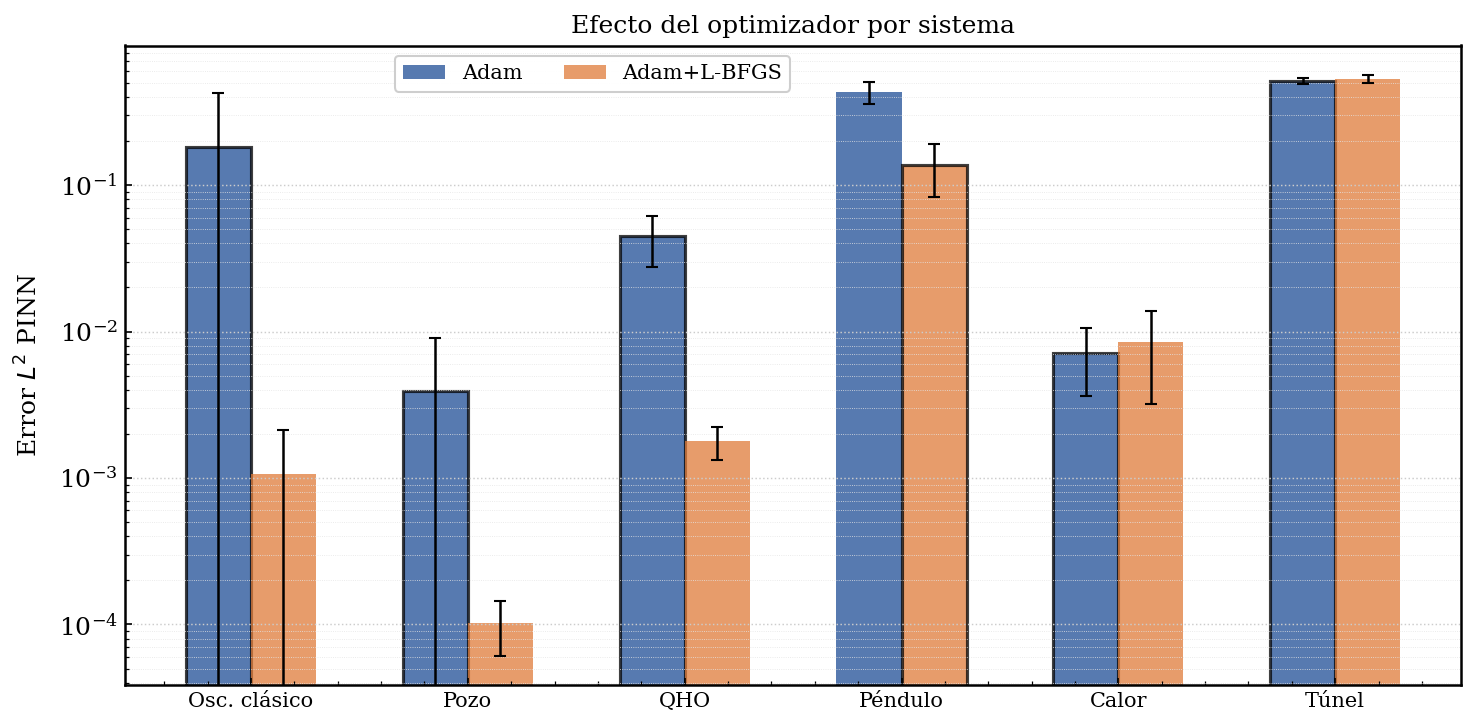


       Sistema           Adam     Adam+LBFGS        Mejor
──────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     1.0619e-03   Adam+LBFGS
          Pozo     3.9263e-03     1.0304e-04   Adam+LBFGS
           QHO     4.4666e-02     1.7897e-03   Adam+LBFGS
       Péndulo     4.3028e-01     1.3603e-01   Adam+LBFGS
         Calor     7.0904e-03     8.5256e-03         Adam
         Túnel     5.1203e-01     5.3209e-01         Adam


In [9]:
opt_vals = ["adam", "adam+lbfgs"]

# ── Recoger medias por sistema y optimizador ──────────────────────────────
rows_opt = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "optimizer", opt_vals)
    for opt, grp in df_all[mask].groupby("optimizer"):
        rows_opt.append({
            "sistema":    s,
            "optimizer":  opt,
            "pinn_mean":  grp["error_l2_pinn"].mean(),
            "pinn_std":   grp["error_l2_pinn"].std(),
            "nn_mean":    grp["error_l2_nn"].mean(),
            "n":          len(grp),
        })

df_opt = pd.DataFrame(rows_opt)

# ── Verificar datos ───────────────────────────────────────────────────────
for s in SISTEMAS_ORDER:
    sub = df_opt[df_opt["sistema"] == s]
    print(f"{s:>14}: {len(sub)} variantes, "
          f"n por variante: {sub['n'].tolist()}")

# ── Gráfica ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SISTEMAS_ORDER))
width = 0.3

adam_means, adam_stds = [], []
lbfgs_means, lbfgs_stds = [], []

for s in SISTEMAS_ORDER:
    sub = df_opt[df_opt["sistema"] == s]
    row_adam = sub[sub["optimizer"] == "adam"]
    row_lbfgs = sub[sub["optimizer"] == "adam+lbfgs"]

    if len(row_adam):
        adam_means.append(row_adam["pinn_mean"].values[0])
        adam_stds.append(row_adam["pinn_std"].values[0])
    else:
        adam_means.append(np.nan)
        adam_stds.append(0)

    if len(row_lbfgs):
        lbfgs_means.append(row_lbfgs["pinn_mean"].values[0])
        lbfgs_stds.append(row_lbfgs["pinn_std"].values[0])
    else:
        lbfgs_means.append(np.nan)
        lbfgs_stds.append(0)

bars1 = ax.bar(x - width/2, adam_means, width, yerr=adam_stds,
               color=C_PINN, alpha=0.75, label="Adam",
               capsize=3, error_kw={"linewidth": 1.2})
bars2 = ax.bar(x + width/2, lbfgs_means, width, yerr=lbfgs_stds,
               color=C_NN, alpha=0.75, label="Adam+L-BFGS",
               capsize=3, error_kw={"linewidth": 1.2})

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto del optimizador por sistema", fontsize=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.35, 1.0), ncol=2,frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)

# ── Marcar BASE de cada sistema ───────────────────────────────────────────
for i, s in enumerate(SISTEMAS_ORDER):
    base_opt = BASE_CONFIGS[s]["optimizer"]
    if base_opt == "adam":
        bars1[i].set_edgecolor("black")
        bars1[i].set_linewidth(1.5)
    else:
        bars2[i].set_edgecolor("black")
        bars2[i].set_linewidth(1.5)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_optimizer.png", dpi=300, bbox_inches="tight")
plt.show()

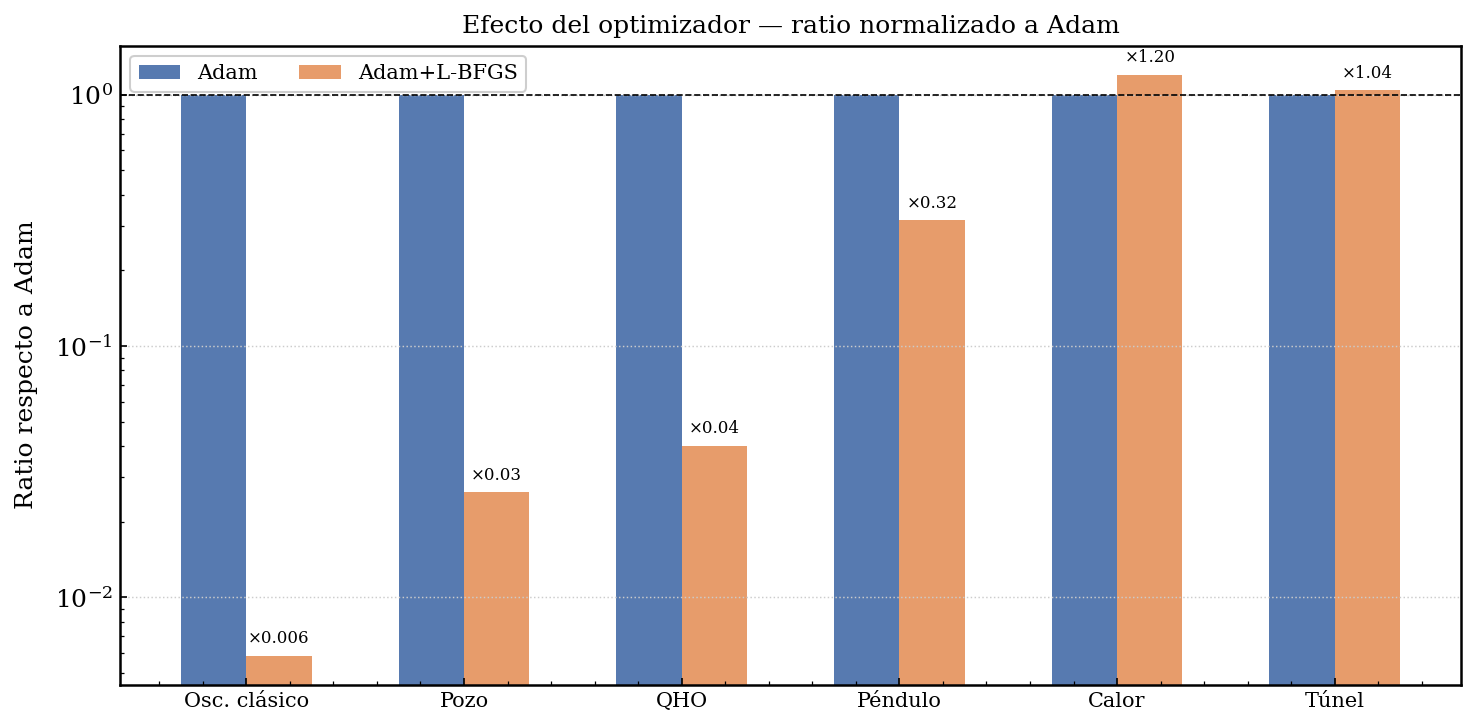


       Sistema           Adam     Adam+LBFGS        Mejor
──────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     1.0619e-03   Adam+LBFGS
          Pozo     3.9263e-03     1.0304e-04   Adam+LBFGS
           QHO     4.4666e-02     1.7897e-03   Adam+LBFGS
       Péndulo     4.3028e-01     1.3603e-01   Adam+LBFGS
         Calor     7.0904e-03     8.5256e-03         Adam
         Túnel     5.1203e-01     5.3209e-01         Adam


In [23]:
# ── Gráfica A: Ratio respecto a Adam (siempre) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SISTEMAS_ORDER))
width = 0.3

adam_ratios = []
lbfgs_ratios = []

for s in SISTEMAS_ORDER:
    sub = df_opt[df_opt["sistema"] == s]
    row_adam  = sub[sub["optimizer"] == "adam"]
    row_lbfgs = sub[sub["optimizer"] == "adam+lbfgs"]

    va = row_adam["pinn_mean"].values[0]  if len(row_adam)  else np.nan
    vl = row_lbfgs["pinn_mean"].values[0] if len(row_lbfgs) else np.nan

    adam_ratios.append(1.0)
    lbfgs_ratios.append(vl / va)

bars1 = ax.bar(x - width/2, adam_ratios, width,
               color=C_PINN, alpha=0.75, label="Adam")
bars2 = ax.bar(x + width/2, lbfgs_ratios, width,
               color=C_NN, alpha=0.75, label="Adam+L-BFGS")

# ── Anotar ratios sobre las barras de L-BFGS ─────────────────────────────
for i in range(len(SISTEMAS_ORDER)):
    ratio = lbfgs_ratios[i]
    bar = bars2[i]
    y_pos = bar.get_height() * 1.05 if ratio >= 1 else bar.get_height() * 0.7
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.08,
            f"×{ratio:.2f}" if ratio >= 0.01 else f"×{ratio:.3f}",
            ha="center", va="bottom", fontsize=8)

ax.axhline(1.0, color="black", linewidth=0.8, linestyle="--", zorder=2)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_ylabel("Ratio respecto a Adam", labelpad=8)
ax.set_title("Efecto del optimizador — ratio normalizado a Adam", fontsize=12)
ax.legend(loc="upper left", ncol=2, frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje1_optimizer_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'Adam':>14} {'Adam+LBFGS':>14} {'Mejor':>12}")
print(f"{'─'*58}")
for s in SISTEMAS_ORDER:
    sub = df_opt[df_opt["sistema"] == s]
    row_a = sub[sub["optimizer"] == "adam"]
    row_l = sub[sub["optimizer"] == "adam+lbfgs"]
    va = row_a["pinn_mean"].values[0] if len(row_a) else np.nan
    vl = row_l["pinn_mean"].values[0] if len(row_l) else np.nan
    mejor = "Adam" if va < vl else "Adam+LBFGS" if vl < va else "—"
    print(f"{s:>14} {va:>14.4e} {vl:>14.4e} {mejor:>12}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\2003356420.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\2003356420.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\2003356420.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\2003356420.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

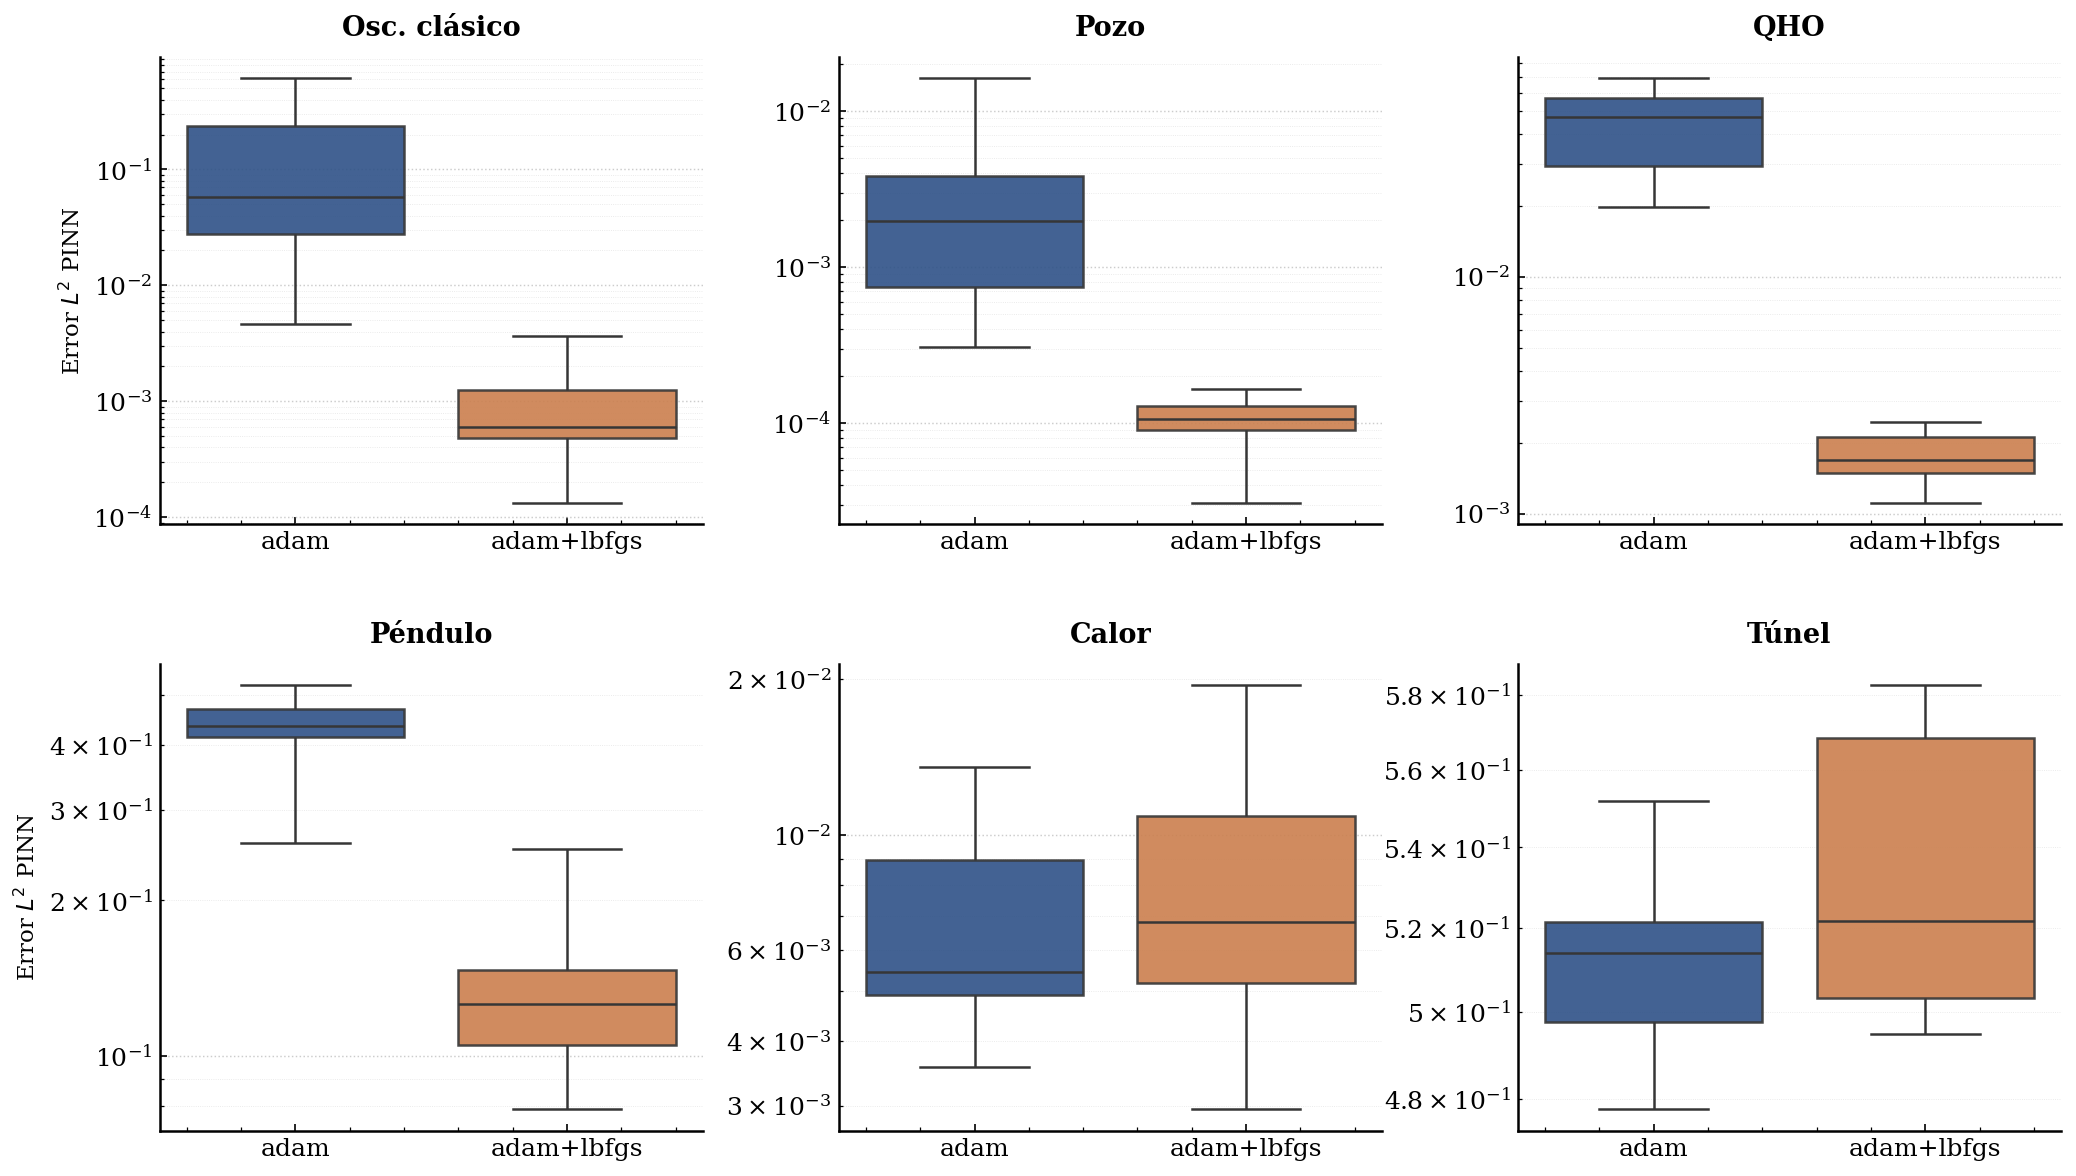

In [26]:
import numpy as np
import pandas as pd

import seaborn as sns


colores = {"adam": C_PINN, "adam+lbfgs": C_NN}

opt_vals = ["adam", "adam+lbfgs"]

# 1. Extraer datos crudos para el Boxplot
rows_raw = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "optimizer", opt_vals)
    df_filtered = df_all[mask].copy()
    rows_raw.append(df_filtered)

df_plot = pd.concat(rows_raw, ignore_index=True)

# ── 2. Crear panel de 2 filas y 3 columnas ────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))
axes = axes.flatten()

for i, s in enumerate(SISTEMAS_ORDER):
    ax = axes[i]
    
    # Filtramos los datos de este sistema específico
    data_sis = df_plot[df_plot["sistema"] == s]
    
    # Dibujamos las cajas solo para este sistema
    sns.boxplot(
        data=data_sis,
        x="optimizer",
        y="error_l2_pinn",
        order=opt_vals,
        palette=colores,
        ax=ax,
        linewidth=1.2,
        whis=(0, 100),           
        boxprops={'alpha': 0.9}
    )
    
    # Escala y formato
    ax.set_yscale("log")
    ax.set_title(s, fontsize=13, weight="bold", pad=10)
    ax.set_xlabel("")
    
    # Solo ponemos la etiqueta del eje Y en los gráficos de la izquierda
    if i % 3 == 0:
        ax.set_ylabel("Error $L^2$ PINN", fontsize=11)
    else:
        ax.set_ylabel("")

    # Cuadrículas y bordes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
    ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.subplots_adjust(wspace=0.25, hspace=0.3)

plt.savefig(FIGS_DIR / "eje1_optimizer_cajas.png", dpi=300, bbox_inches="tight")
plt.show()

## Eje 2 — Learning rate (0.001 vs 0.01)

Comparativa transversal del efecto de la tasa de aprendizaje en los 6 sistemas.
En todos los casos el BASE es lr=0.001. El learning rate afecta tanto a la
PINN como a la NN, pero aquí se compara solo el error L2 de la PINN.

  Osc. clásico: 2 variantes, n por variante: [10, 10]
          Pozo: 2 variantes, n por variante: [10, 10]
           QHO: 2 variantes, n por variante: [10, 10]
       Péndulo: 2 variantes, n por variante: [10, 10]
         Calor: 2 variantes, n por variante: [10, 10]
         Túnel: 2 variantes, n por variante: [10, 10]


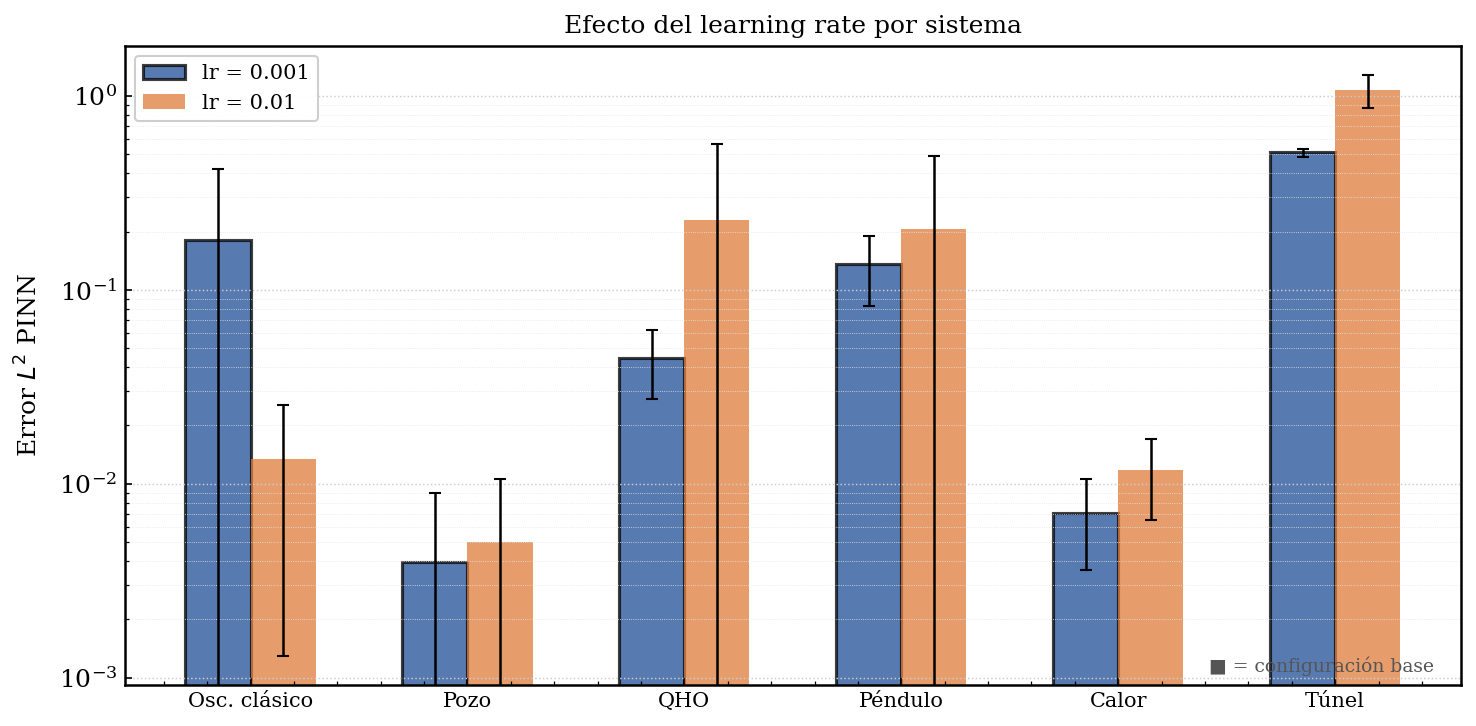


       Sistema       lr=0.001        lr=0.01        Mejor
──────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     1.3356e-02         0.01
          Pozo     3.9263e-03     5.0146e-03        0.001
           QHO     4.4666e-02     2.3056e-01        0.001
       Péndulo     1.3603e-01     2.0549e-01        0.001
         Calor     7.0904e-03     1.1763e-02        0.001
         Túnel     5.1203e-01     1.0807e+00        0.001


In [14]:
lr_vals = [0.001, 0.01]

rows_lr = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "lr", lr_vals)
    for lr, grp in df_all[mask].groupby("lr"):
        rows_lr.append({
            "sistema":   s,
            "lr":        lr,
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "pinn_std":  grp["error_l2_pinn"].std(),
            "n":         len(grp),
        })

df_lr = pd.DataFrame(rows_lr)

for s in SISTEMAS_ORDER:
    sub = df_lr[df_lr["sistema"] == s]
    print(f"{s:>14}: {len(sub)} variantes, "
          f"n por variante: {sub['n'].tolist()}")

# ── Gráfica ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SISTEMAS_ORDER))
width = 0.3

lr001_means, lr001_stds = [], []
lr01_means, lr01_stds = [], []

for s in SISTEMAS_ORDER:
    sub = df_lr[df_lr["sistema"] == s]
    row_001 = sub[sub["lr"] == 0.001]
    row_01  = sub[sub["lr"] == 0.01]

    if len(row_001):
        lr001_means.append(row_001["pinn_mean"].values[0])
        lr001_stds.append(row_001["pinn_std"].values[0])
    else:
        lr001_means.append(np.nan)
        lr001_stds.append(0)

    if len(row_01):
        lr01_means.append(row_01["pinn_mean"].values[0])
        lr01_stds.append(row_01["pinn_std"].values[0])
    else:
        lr01_means.append(np.nan)
        lr01_stds.append(0)

bars1 = ax.bar(x - width/2, lr001_means, width, yerr=lr001_stds,
               color=C_PINN, alpha=0.75, label="lr = 0.001",
               capsize=3, error_kw={"linewidth": 1.2})
bars2 = ax.bar(x + width/2, lr01_means, width, yerr=lr01_stds,
               color=C_NN, alpha=0.75, label="lr = 0.01",
               capsize=3, error_kw={"linewidth": 1.2})

# ── Marcar BASE (siempre lr=0.001) ───────────────────────────────────────
for i in range(len(SISTEMAS_ORDER)):
    bars1[i].set_edgecolor("black")
    bars1[i].set_linewidth(1.5)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto del learning rate por sistema", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)

ax.annotate("■ = configuración base", xy=(0.98, 0.02),
            xycoords="axes fraction", ha="right", fontsize=9,
            color="#555555")

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_lr.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'lr=0.001':>14} {'lr=0.01':>14} {'Mejor':>12}")
print(f"{'─'*58}")
for s in SISTEMAS_ORDER:
    sub = df_lr[df_lr["sistema"] == s]
    row_001 = sub[sub["lr"] == 0.001]
    row_01  = sub[sub["lr"] == 0.01]
    v001 = row_001["pinn_mean"].values[0] if len(row_001) else np.nan
    v01  = row_01["pinn_mean"].values[0]  if len(row_01)  else np.nan
    mejor = "0.001" if v001 < v01 else "0.01" if v01 < v001 else "—"
    print(f"{s:>14} {v001:>14.4e} {v01:>14.4e} {mejor:>12}")

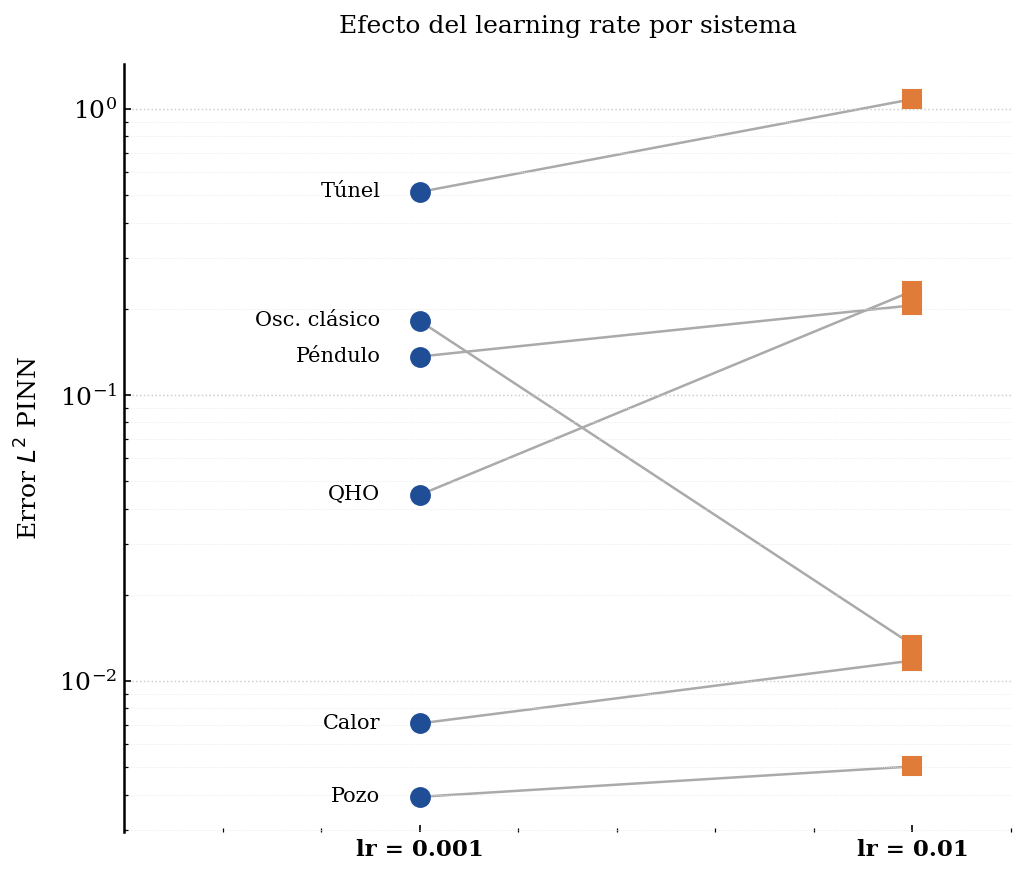


       Sistema       lr=0.001        lr=0.01        Mejor
──────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     1.3356e-02         0.01
          Pozo     3.9263e-03     5.0146e-03        0.001
           QHO     4.4666e-02     2.3056e-01        0.001
       Péndulo     1.3603e-01     2.0549e-01        0.001
         Calor     7.0904e-03     1.1763e-02        0.001
         Túnel     5.1203e-01     1.0807e+00        0.001


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


lr_vals = [0.001, 0.01]

# ── Recoger medias por sistema y learning rate ────────────────────────────
rows_lr = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "lr", lr_vals)
    for lr, grp in df_all[mask].groupby("lr"):
        rows_lr.append({
            "sistema":   s,
            "lr":        lr,
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "n":         len(grp),
        })

df_lr = pd.DataFrame(rows_lr)

# ── Gráfica (Slope Chart / Paired dot plot) ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6)) # Un poco más cuadrado para destacar las pendientes

for i, s in enumerate(SISTEMAS_ORDER):
    sub = df_lr[df_lr["sistema"] == s]
    row_001 = sub[sub["lr"] == 0.001]
    row_01  = sub[sub["lr"] == 0.01]

    # Extraer las medias (vf = lr 0.001, vd = lr 0.01)
    vf = row_001["pinn_mean"].values[0] if len(row_001) else np.nan
    vd = row_01["pinn_mean"].values[0]  if len(row_01)  else np.nan

    if np.isnan(vf) or np.isnan(vd):
        continue # Si falta un dato, no dibujamos esa línea

    # Dibujar línea conectora y los dos puntos
    ax.plot([0, 1], [vf, vd], color="#aaaaaa", linewidth=1.2, zorder=1)
    ax.plot(0, vf, "o", color=C_PINN, markersize=9, zorder=3)
    ax.plot(1, vd, "s", color=C_NN, markersize=9, zorder=3)

    # Etiqueta del sistema a la izquierda del punto inicial
    ax.text(-0.08, vf, s, va="center", ha="right", fontsize=10)

# Formato de ejes
ax.set_yscale("log")
ax.set_xlim(-0.6, 1.2) # Ampliamos la izquierda para que quepan los nombres
ax.set_xticks([0, 1])
ax.set_xticklabels(["lr = 0.001", "lr = 0.01"], fontsize=11, weight="bold")
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto del learning rate por sistema", fontsize=12, pad=15)

# Limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False) # Quitar el eje X inferior queda más limpio aquí
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# ── Leyenda compartida ───────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_PINN,
           markersize=9, label="lr = 0.001 (BASE)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_NN,
           markersize=9, label="lr = 0.01"),
]



plt.tight_layout()
plt.savefig(FIGS_DIR / "eje2_lr_slope.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'lr=0.001':>14} {'lr=0.01':>14} {'Mejor':>12}")
print(f"{'─'*58}")
for s in SISTEMAS_ORDER:
    sub = df_lr[df_lr["sistema"] == s]
    row_001 = sub[sub["lr"] == 0.001]
    row_01  = sub[sub["lr"] == 0.01]
    v001 = row_001["pinn_mean"].values[0] if len(row_001) else np.nan
    v01  = row_01["pinn_mean"].values[0]  if len(row_01)  else np.nan
    mejor = "0.001" if v001 < v01 else "0.01" if v01 < v001 else "—"
    print(f"{s:>14} {v001:>14.4e} {v01:>14.4e} {mejor:>12}")

## Eje 3 — Pesos dinámicos (fijos vs activados)

Los pesos dinámicos solo afectan a la PINN. Se visualiza mediante un
dumbbell plot: cada sistema tiene un punto para pesos fijos y otro para
dinámicos, conectados por una línea. Si la línea va hacia la izquierda
(menor error), los pesos dinámicos mejoran el rendimiento.

  Osc. clásico: 2 variantes, n por variante: [10, 10]
          Pozo: 2 variantes, n por variante: [10, 10]
           QHO: 2 variantes, n por variante: [10, 10]
       Péndulo: 2 variantes, n por variante: [10, 10]
         Calor: 2 variantes, n por variante: [10, 10]
         Túnel: 2 variantes, n por variante: [10, 10]


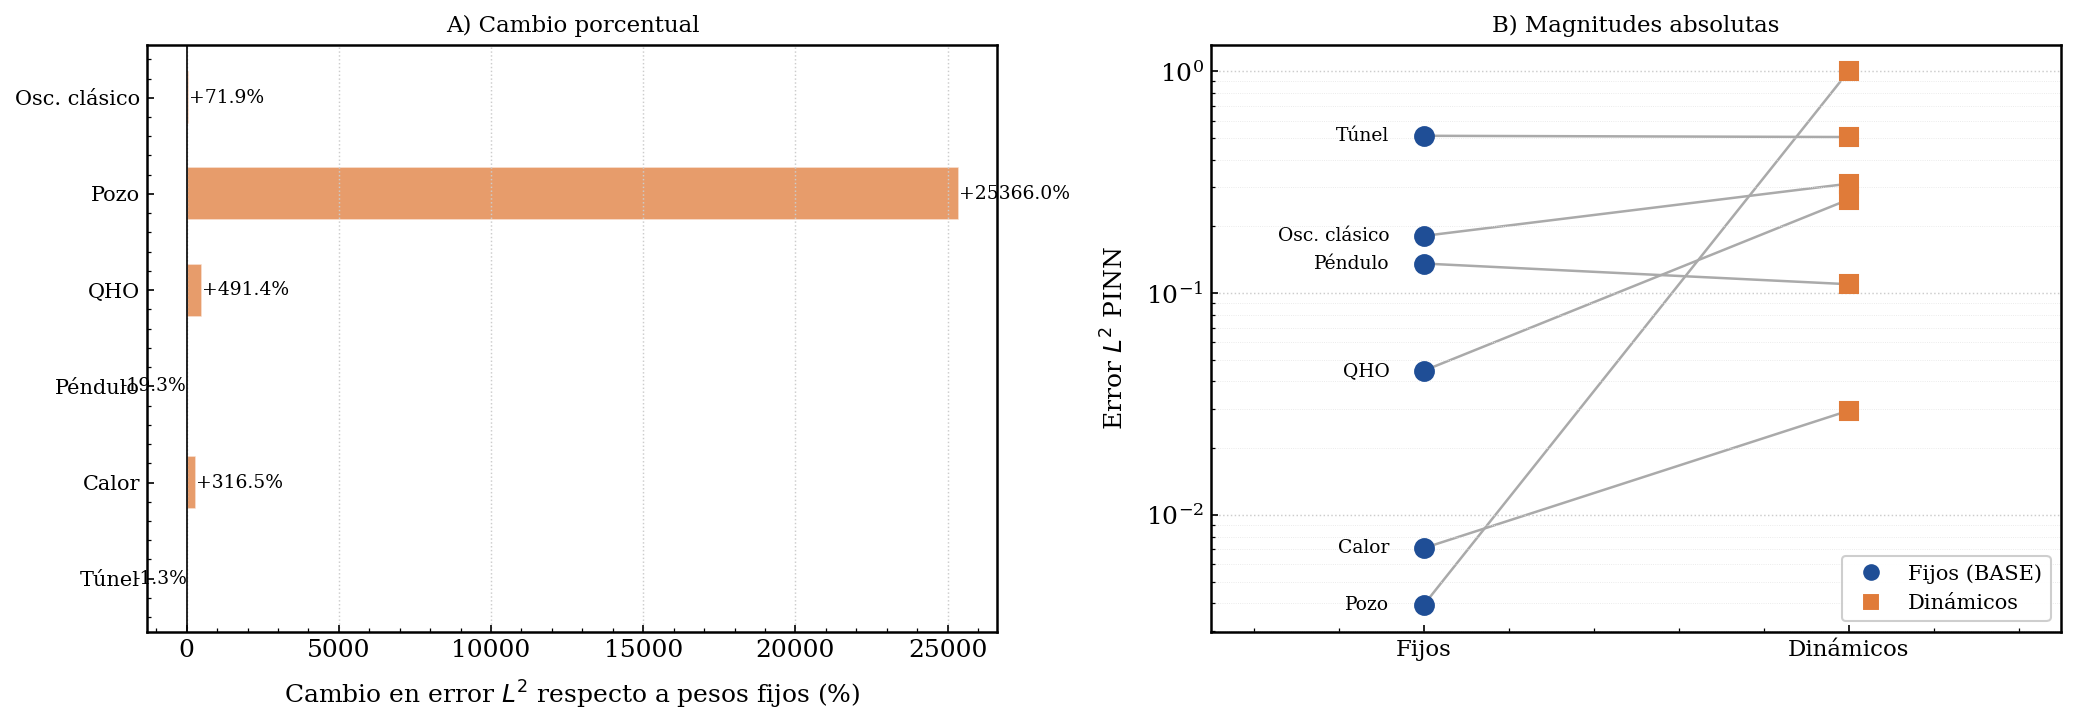


       Sistema          Fijos      Dinámicos         Δ%        Mejor
────────────────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     3.1139e-01      +71.9%        Fijos
          Pozo     3.9263e-03     9.9988e-01   +25366.0%        Fijos
           QHO     4.4666e-02     2.6414e-01     +491.4%        Fijos
       Péndulo     1.3603e-01     1.0973e-01      -19.3%    Dinámicos
         Calor     7.0904e-03     2.9533e-02     +316.5%        Fijos
         Túnel     5.1203e-01     5.0547e-01       -1.3%    Dinámicos


In [35]:
dw_vals = [False, True]

rows_dw = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "use_dynamic_weights", dw_vals)
    for dw, grp in df_all[mask].groupby("use_dynamic_weights"):
        rows_dw.append({
            "sistema":   s,
            "dw":        "Dinámicos" if dw else "Fijos",
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "pinn_std":  grp["error_l2_pinn"].std(),
            "n":         len(grp),
        })

df_dw = pd.DataFrame(rows_dw)

for s in SISTEMAS_ORDER:
    sub = df_dw[df_dw["sistema"] == s]
    print(f"{s:>14}: {len(sub)} variantes, "
          f"n por variante: {sub['n'].tolist()}")

# ── Calcular ratios ───────────────────────────────────────────────────────
delta_pct = []
v_fijos_list = []
v_din_list = []

for s in SISTEMAS_ORDER:
    sub = df_dw[df_dw["sistema"] == s]
    vf = sub[sub["dw"] == "Fijos"]["pinn_mean"].values[0]
    vd = sub[sub["dw"] == "Dinámicos"]["pinn_mean"].values[0]
    delta_pct.append((vd - vf) / vf * 100)
    v_fijos_list.append(vf)
    v_din_list.append(vd)

# ── Opción A: Bar chart horizontal del % de cambio ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
y_pos = np.arange(len(SISTEMAS_ORDER))
colors_a = [C_PINN if d < 0 else C_NN for d in delta_pct]

bars = ax.barh(y_pos, delta_pct, color=colors_a, alpha=0.75,
               edgecolor="white", linewidth=0.8, height=0.55)
ax.axvline(0, color="black", linewidth=0.8, zorder=2)

for i, (d, bar) in enumerate(zip(delta_pct, bars)):
    ha = "left" if d >= 0 else "right"
    offset = 1.5 if d >= 0 else -1.5
    ax.text(d + offset, i, f"{d:+.1f}%", va="center", ha=ha, fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_xlabel("Cambio en error $L^2$ respecto a pesos fijos (%)", labelpad=8)
ax.set_title("A) Cambio porcentual", fontsize=11)
ax.invert_yaxis()
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)

# ── Opción B: Paired dot plot ─────────────────────────────────────────────
ax = axes[1]

for i, s in enumerate(SISTEMAS_ORDER):
    vf = v_fijos_list[i]
    vd = v_din_list[i]
    ax.plot([0, 1], [vf, vd], color="#aaaaaa", linewidth=1.2, zorder=1)
    ax.plot(0, vf, "o", color=C_PINN, markersize=9, zorder=3)
    ax.plot(1, vd, "s", color=C_NN, markersize=9, zorder=3)

    y_label = vf
    ax.text(-0.08, y_label, s, va="center", ha="right", fontsize=9)

ax.set_yscale("log")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Fijos", "Dinámicos"], fontsize=11)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("B) Magnitudes absolutas", fontsize=11)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)

# ── Leyenda compartida ───────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_PINN,
           markersize=9, label="Fijos (BASE)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_NN,
           markersize=9, label="Dinámicos"),
]
ax.legend(handles=legend_elements, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje3_dynamic_weights.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'Fijos':>14} {'Dinámicos':>14} {'Δ%':>10} {'Mejor':>12}")
print(f"{'─'*68}")
for i, s in enumerate(SISTEMAS_ORDER):
    vf = v_fijos_list[i]
    vd = v_din_list[i]
    d = delta_pct[i]
    mejor = "Fijos" if vf < vd else "Dinámicos" if vd < vf else "—"
    print(f"{s:>14} {vf:>14.4e} {vd:>14.4e} {d:>+10.1f}% {mejor:>12}")

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

dw_vals = [False, True]

rows_dw = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "use_dynamic_weights", dw_vals)
    for dw, grp in df_all[mask].groupby("use_dynamic_weights"):
        rows_dw.append({
            "sistema":   s,
            "dw":        "Dinámicos" if dw else "Fijos",
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "pinn_std":  grp["error_l2_pinn"].std(),
            "n":         len(grp),
        })

df_dw = pd.DataFrame(rows_dw)

# ── Calcular ratios ───────────────────────────────────────────────────────
delta_pct = []
v_fijos_list = []
v_din_list = []

for s in SISTEMAS_ORDER:
    sub = df_dw[df_dw["sistema"] == s]
    vf = sub[sub["dw"] == "Fijos"]["pinn_mean"].values[0]
    vd = sub[sub["dw"] == "Dinámicos"]["pinn_mean"].values[0]
    delta_pct.append((vd - vf) / vf * 100)
    v_fijos_list.append(vf)
    v_din_list.append(vd)

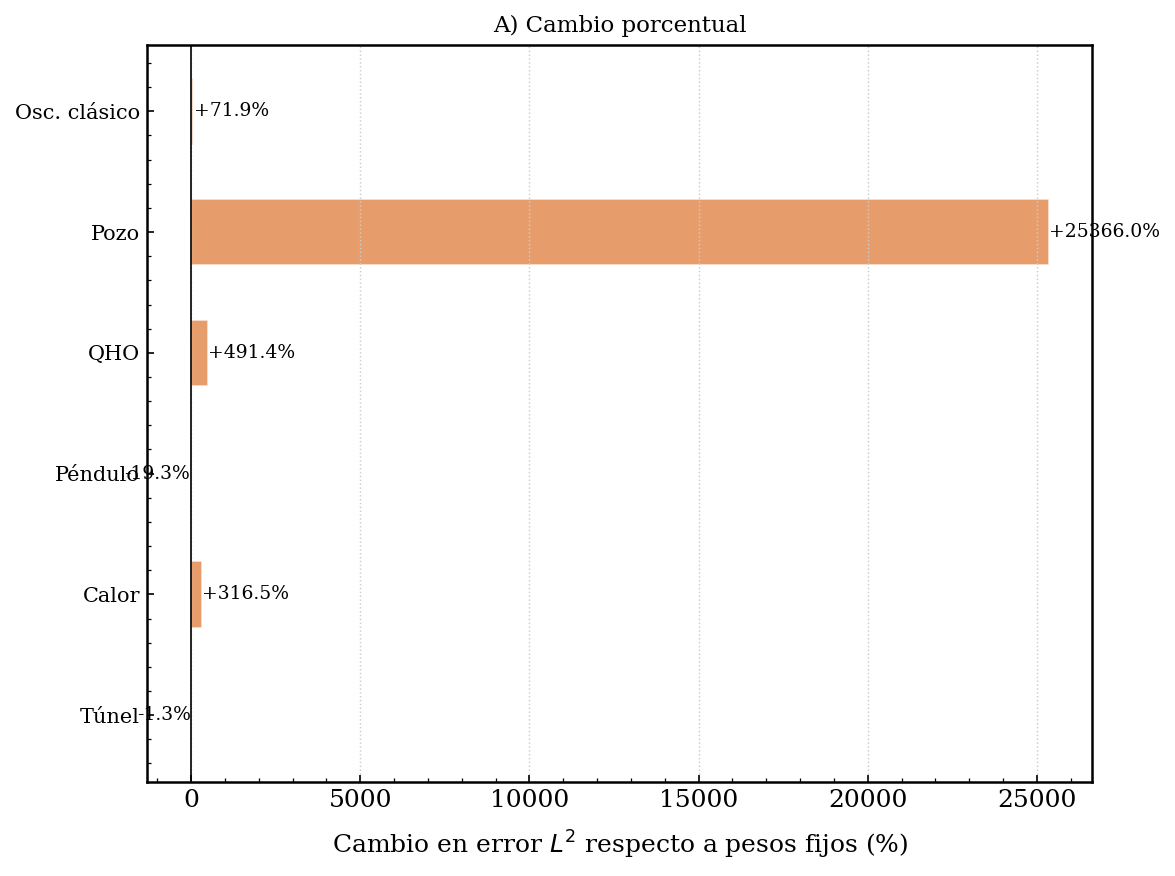

In [38]:
# ── Opción A: Bar chart horizontal del % de cambio ───────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(SISTEMAS_ORDER))
colors_a = [C_PINN if d < 0 else C_NN for d in delta_pct]

bars = ax.barh(y_pos, delta_pct, color=colors_a, alpha=0.75,
               edgecolor="white", linewidth=0.8, height=0.55)
ax.axvline(0, color="black", linewidth=0.8, zorder=2)

for i, (d, bar) in enumerate(zip(delta_pct, bars)):
    ha = "left" if d >= 0 else "right"
    offset = 1.5 if d >= 0 else -1.5
    ax.text(d + offset, i, f"{d:+.1f}%", va="center", ha=ha, fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_xlabel("Cambio en error $L^2$ respecto a pesos fijos (%)", labelpad=8)
ax.set_title("A) Cambio porcentual", fontsize=11)
ax.invert_yaxis()
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)

plt.tight_layout()
# plt.savefig(FIGS_DIR / "eje3_dynamic_weights_porcentual.png", dpi=300, bbox_inches="tight")
plt.show()

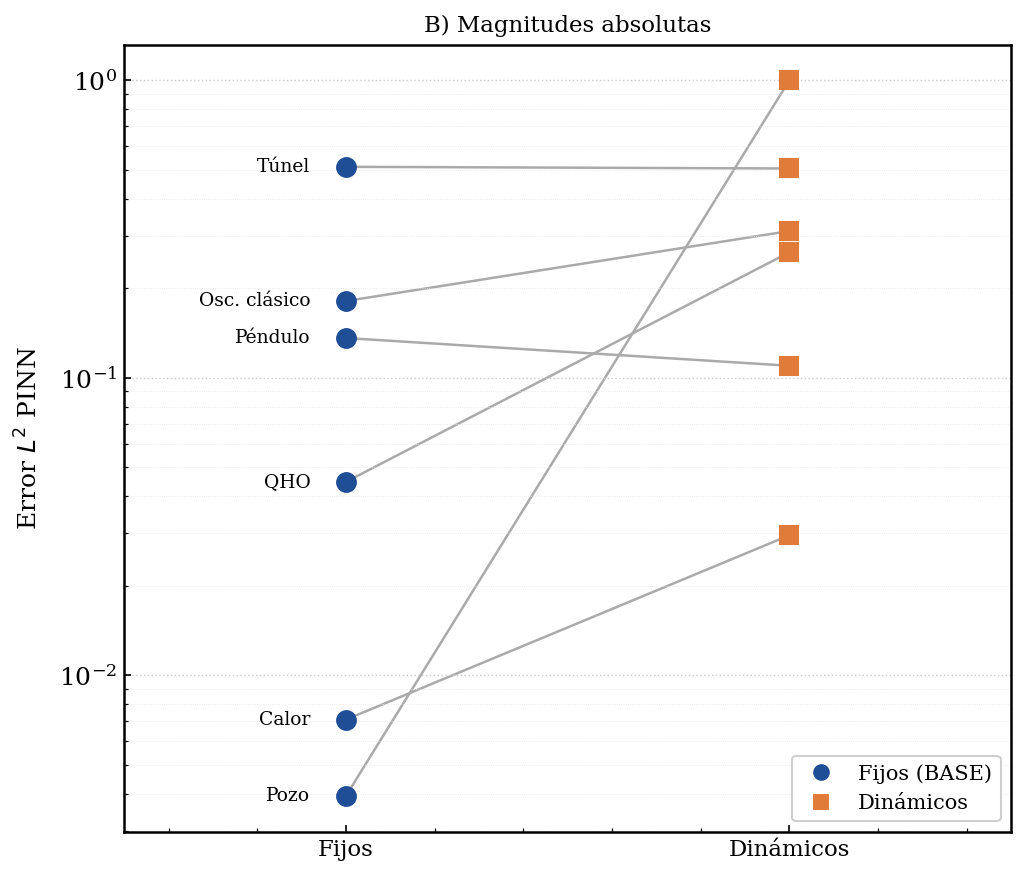

In [39]:
# ── Opción B: Paired dot plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for i, s in enumerate(SISTEMAS_ORDER):
    vf = v_fijos_list[i]
    vd = v_din_list[i]
    ax.plot([0, 1], [vf, vd], color="#aaaaaa", linewidth=1.2, zorder=1)
    ax.plot(0, vf, "o", color=C_PINN, markersize=9, zorder=3)
    ax.plot(1, vd, "s", color=C_NN, markersize=9, zorder=3)

    y_label = vf
    ax.text(-0.08, y_label, s, va="center", ha="right", fontsize=9)

ax.set_yscale("log")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Fijos", "Dinámicos"], fontsize=11)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("B) Magnitudes absolutas", fontsize=11)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)

# ── Leyenda compartida ───────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_PINN,
           markersize=9, label="Fijos (BASE)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=C_NN,
           markersize=9, label="Dinámicos"),
]
ax.legend(handles=legend_elements, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", fontsize=10, loc="lower right")

plt.tight_layout()
# plt.savefig(FIGS_DIR / "eje3_dynamic_weights_absoluto.png", dpi=300, bbox_inches="tight")
plt.show()

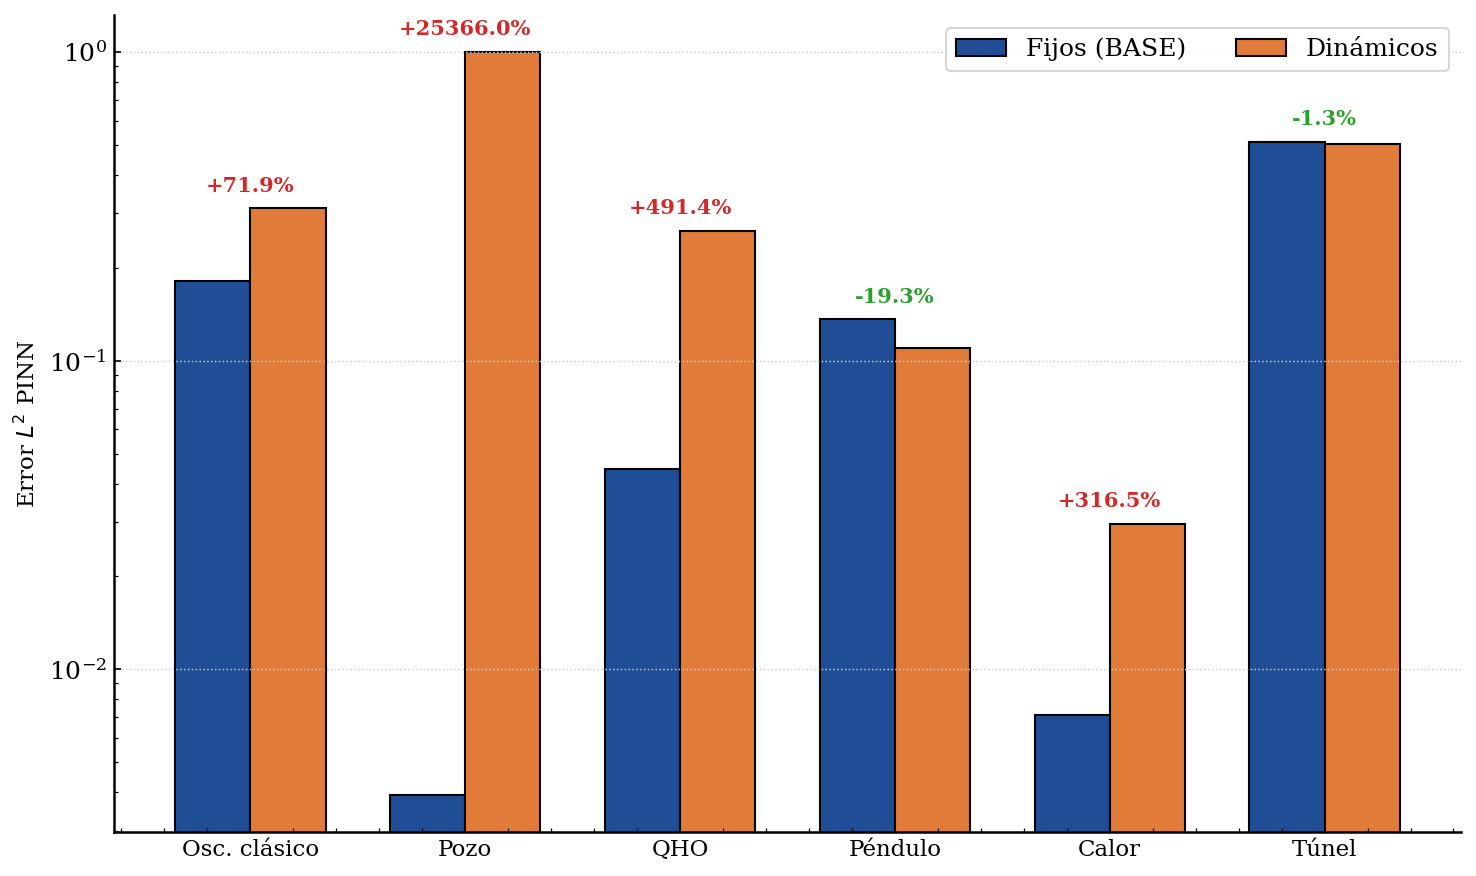

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(SISTEMAS_ORDER))
width = 0.35

# Barras de valores absolutos
ax.bar(x - width/2, v_fijos_list, width, label='Fijos (BASE)', color=C_PINN, edgecolor="black", linewidth=1)
ax.bar(x + width/2, v_din_list, width, label='Dinámicos', color=C_NN, edgecolor="black", linewidth=1)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=11)
ax.set_ylabel("Error $L^2$ PINN", fontsize=11)

# Añadir el texto del Δ% justo encima de cada par de barras
for i in range(len(SISTEMAS_ORDER)):
    d = delta_pct[i]
    # Calculamos la altura máxima del par para poner el texto encima
    max_y = max(v_fijos_list[i], v_din_list[i])
    # Ajustamos el texto: verde si mejora (negativo), rojo si empeora (positivo)
    color_txt = "#2ca02c" if d < 0 else "#d62728"
    
    ax.text(x[i], max_y * 1.1, f"{d:+.1f}%", ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color=color_txt)

# Cuadrícula y limpieza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

ax.legend(loc="upper right", ncol=2, frameon=True, edgecolor="#cccccc")

plt.savefig(FIGS_DIR / "eje3_dynamic_weights_absoluto.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

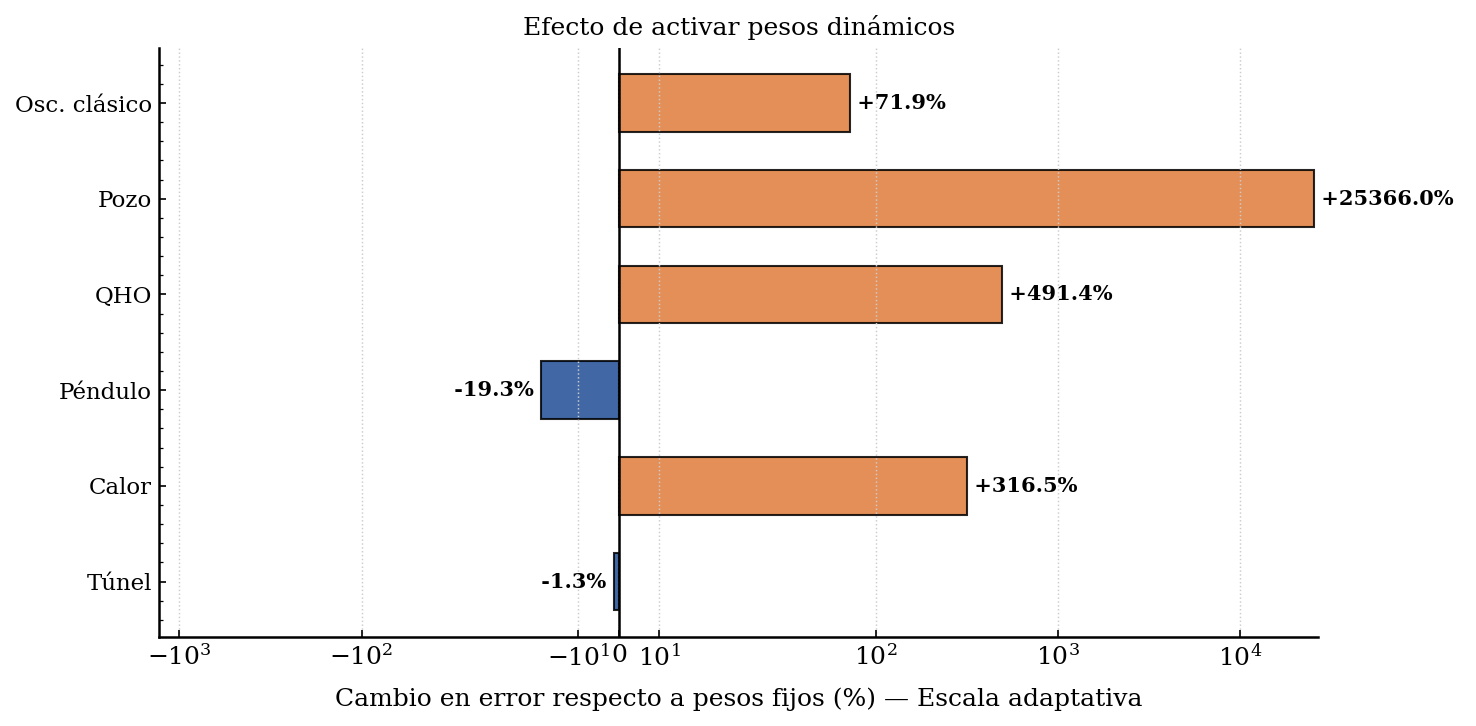

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(SISTEMAS_ORDER))
colors_a = [C_PINN if d < 0 else C_NN for d in delta_pct]

# Barras horizontales idénticas a tu código
bars = ax.barh(y_pos, delta_pct, color=colors_a, alpha=0.85,
               edgecolor="black", linewidth=1, height=0.6)

# Línea del cero
ax.axvline(0, color="black", linewidth=1.2, zorder=2)

# La clave para que el 25000% no destroce la gráfica
ax.set_xscale('symlog', linthresh=50)

# Imprimir los porcentajes al lado de cada barra
for i, (d, bar) in enumerate(zip(delta_pct, bars)):
    ha = "left" if d >= 0 else "right"
    # Añadimos un espacio vacío en el f-string para que no se pegue a la línea
    texto = f" {d:+.1f}% " if d >= 0 else f" {d:+.1f}% "
    ax.text(d, i, texto, va="center", ha=ha, fontsize=10, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=11)
ax.set_xlabel("Cambio en error respecto a pesos fijos (%) — Escala adaptativa", labelpad=8)
ax.set_title("Efecto de activar pesos dinámicos", fontsize=12)
ax.invert_yaxis()

# Cuadrícula y bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
plt.show()

## Eje 4 — Sampler (LHS vs grid)

El sampler solo afecta a los puntos de colocación de la PINN, no a la NN pura.
Se presentan dos visualizaciones: un grouped bar chart vertical y un bar chart
horizontal del cambio porcentual respecto a LHS (BASE).

  Osc. clásico: 2 variantes, n por variante: [10, 10]
          Pozo: 2 variantes, n por variante: [10, 10]
           QHO: 2 variantes, n por variante: [10, 10]
       Péndulo: 2 variantes, n por variante: [10, 10]
         Calor: 2 variantes, n por variante: [10, 10]
         Túnel: 2 variantes, n por variante: [10, 10]


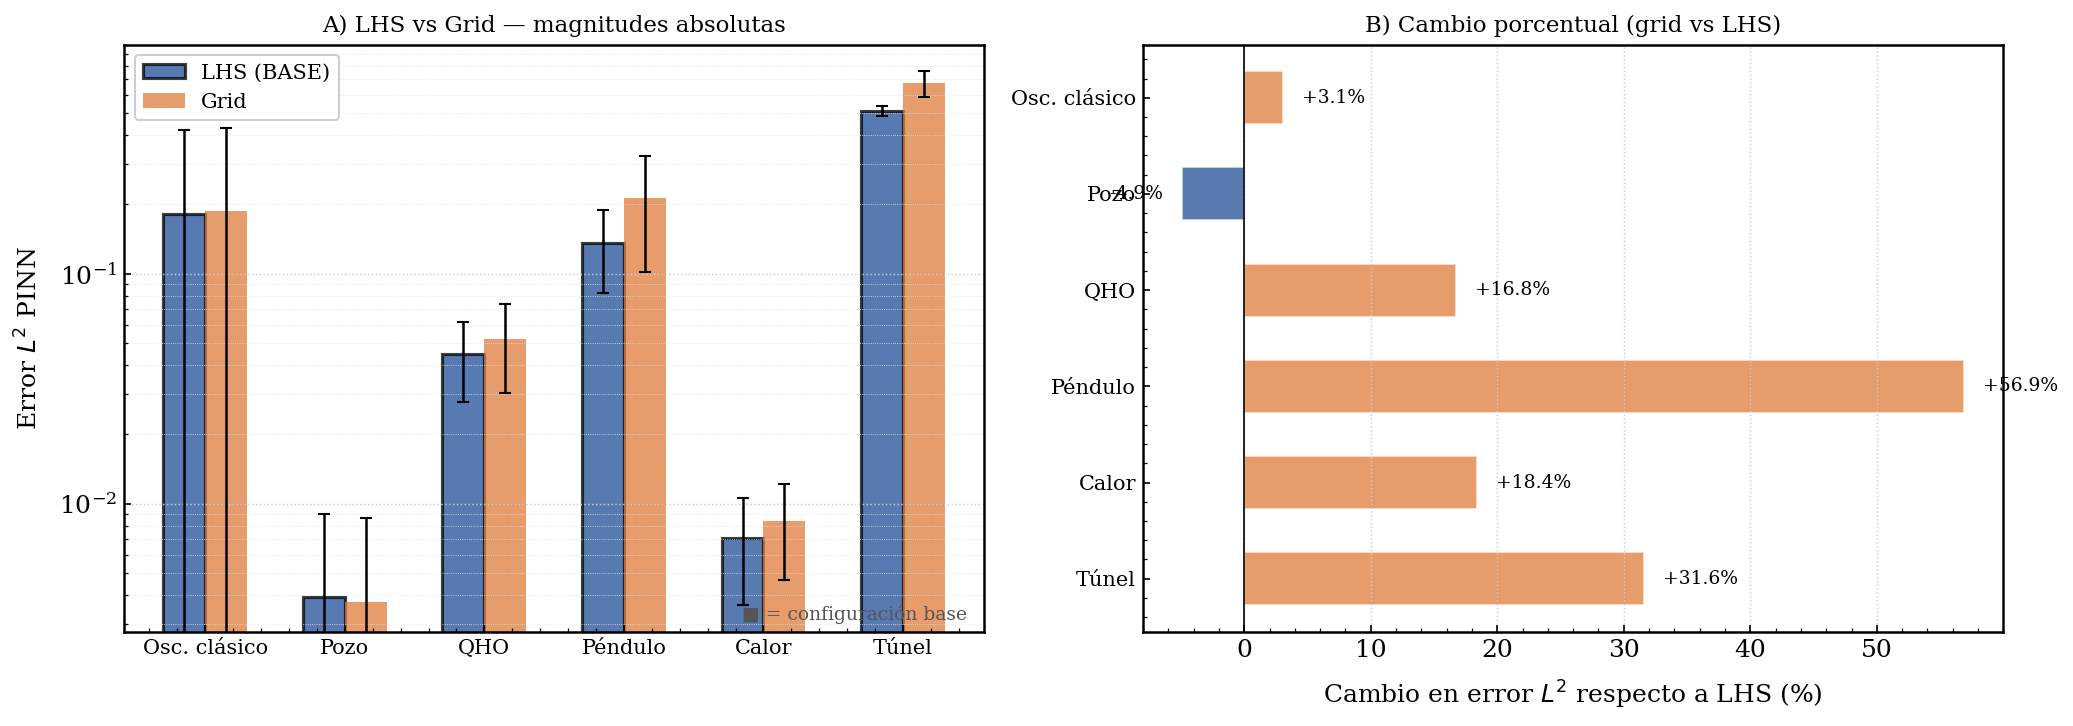


       Sistema            LHS           Grid         Δ%        Mejor
────────────────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     1.8670e-01       +3.1%          LHS
          Pozo     3.9263e-03     3.7348e-03       -4.9%         Grid
           QHO     4.4666e-02     5.2156e-02      +16.8%          LHS
       Péndulo     1.3603e-01     2.1343e-01      +56.9%          LHS
         Calor     7.0904e-03     8.3935e-03      +18.4%          LHS
         Túnel     5.1203e-01     6.7374e-01      +31.6%          LHS


In [55]:
sampler_vals = ["lhs", "grid"]

rows_sampler = []
for s in SISTEMAS_ORDER:
    mask = get_variant_mask(s, "sampler", sampler_vals)
    for smp, grp in df_all[mask].groupby("sampler"):
        rows_sampler.append({
            "sistema":   s,
            "sampler":   smp,
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "pinn_std":  grp["error_l2_pinn"].std(),
            "n":         len(grp),
        })

df_sampler = pd.DataFrame(rows_sampler)

for s in SISTEMAS_ORDER:
    sub = df_sampler[df_sampler["sistema"] == s]
    print(f"{s:>14}: {len(sub)} variantes, "
          f"n por variante: {sub['n'].tolist()}")

# ── Preparar datos ────────────────────────────────────────────────────────
lhs_means, lhs_stds = [], []
grid_means, grid_stds = [], []
delta_pct_sampler = []

for s in SISTEMAS_ORDER:
    sub = df_sampler[df_sampler["sistema"] == s]
    row_lhs  = sub[sub["sampler"] == "lhs"]
    row_grid = sub[sub["sampler"] == "grid"]

    vl = row_lhs["pinn_mean"].values[0]  if len(row_lhs)  else np.nan
    sl = row_lhs["pinn_std"].values[0]   if len(row_lhs)  else 0
    vg = row_grid["pinn_mean"].values[0] if len(row_grid) else np.nan
    sg = row_grid["pinn_std"].values[0]  if len(row_grid) else 0

    lhs_means.append(vl)
    lhs_stds.append(sl)
    grid_means.append(vg)
    grid_stds.append(sg)
    delta_pct_sampler.append((vg - vl) / vl * 100)

# ── Gráficas ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── A) Grouped bar chart vertical ────────────────────────────────────────
ax = axes[0]
x = np.arange(len(SISTEMAS_ORDER))
width = 0.3

bars1 = ax.bar(x - width/2, lhs_means, width, yerr=lhs_stds,
               color=C_PINN, alpha=0.75, label="LHS (BASE)",
               capsize=3, error_kw={"linewidth": 1.2})
bars2 = ax.bar(x + width/2, grid_means, width, yerr=grid_stds,
               color=C_NN, alpha=0.75, label="Grid",
               capsize=3, error_kw={"linewidth": 1.2})

for i in range(len(SISTEMAS_ORDER)):
    bars1[i].set_edgecolor("black")
    bars1[i].set_linewidth(1.5)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("A) LHS vs Grid — magnitudes absolutas", fontsize=11)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)
ax.annotate("■ = configuración base", xy=(0.98, 0.02),
            xycoords="axes fraction", ha="right", fontsize=9,
            color="#555555")

# ── B) Bar chart horizontal del % de cambio ──────────────────────────────
ax = axes[1]
y_pos = np.arange(len(SISTEMAS_ORDER))
colors_s = [C_PINN if d < 0 else C_NN for d in delta_pct_sampler]

bars = ax.barh(y_pos, delta_pct_sampler, color=colors_s, alpha=0.75,
               edgecolor="white", linewidth=0.8, height=0.55)
ax.axvline(0, color="black", linewidth=0.8, zorder=2)

for i, (d, bar) in enumerate(zip(delta_pct_sampler, bars)):
    ha = "left" if d >= 0 else "right"
    offset = 1.5 if d >= 0 else -1.5
    ax.text(d + offset, i, f"{d:+.1f}%", va="center", ha=ha, fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_xlabel("Cambio en error $L^2$ respecto a LHS (%)", labelpad=8)
ax.set_title("B) Cambio porcentual (grid vs LHS)", fontsize=11)
ax.invert_yaxis()
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_sampler.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'LHS':>14} {'Grid':>14} {'Δ%':>10} {'Mejor':>12}")
print(f"{'─'*68}")
for i, s in enumerate(SISTEMAS_ORDER):
    vl = lhs_means[i]
    vg = grid_means[i]
    d = delta_pct_sampler[i]
    mejor = "LHS" if vl < vg else "Grid" if vg < vl else "—"
    print(f"{s:>14} {vl:>14.4e} {vg:>14.4e} {d:>+10.1f}% {mejor:>12}")

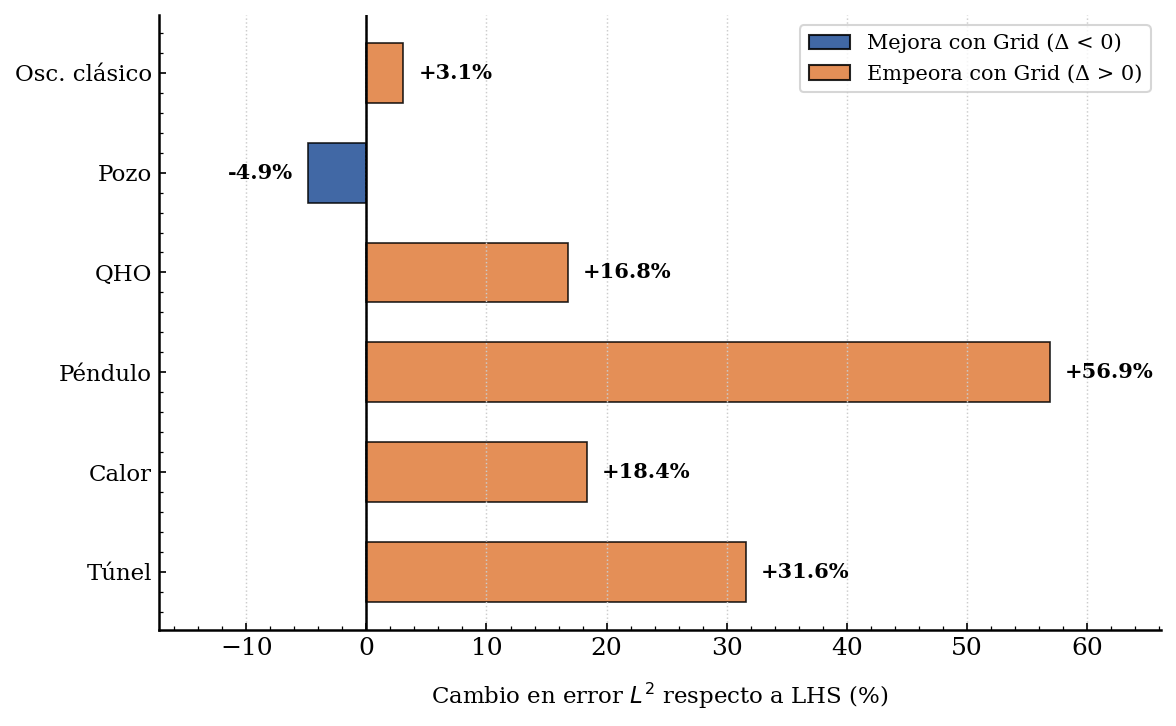

In [60]:
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# ── 1. Preparar datos ─────────────────────────────────────────────────────
delta_pct_sampler = []

for s in SISTEMAS_ORDER:
    sub = df_sampler[df_sampler["sistema"] == s]
    row_lhs  = sub[sub["sampler"] == "lhs"]
    row_grid = sub[sub["sampler"] == "grid"]

    vl = row_lhs["pinn_mean"].values[0]  if len(row_lhs)  else np.nan
    vg = row_grid["pinn_mean"].values[0] if len(row_grid) else np.nan
    
    delta_pct_sampler.append((vg - vl) / vl * 100)

# ── 2. Gráfica: Bar chart horizontal del % de cambio ──────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(SISTEMAS_ORDER))
colors_s = [C_PINN if d < 0 else C_NN for d in delta_pct_sampler]

bars = ax.barh(y_pos, delta_pct_sampler, color=colors_s, alpha=0.85,
               edgecolor="black", linewidth=0.8, height=0.6)

# Línea del cero
ax.axvline(0, color="black", linewidth=1.2, zorder=2)

# ── FIX: Ajustar los límites del eje X para que el texto no se solape ─────
val_min = min(min(delta_pct_sampler), 0)
val_max = max(max(delta_pct_sampler), 0)
rango = val_max - val_min
# Damos un 20% de margen a la izquierda y un 15% a la derecha
ax.set_xlim(val_min - (rango * 0.20), val_max + (rango * 0.15))

# Textos con los porcentajes
for i, (d, bar) in enumerate(zip(delta_pct_sampler, bars)):
    ha = "left" if d >= 0 else "right"
    # Offset dinámico basado en el rango para que sea proporcional
    offset = rango * 0.02 if d >= 0 else -rango * 0.02
    ax.text(d + offset, i, f"{d:+.1f}%", va="center", ha=ha, fontsize=10, weight="bold")

# Formato de ejes
ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=11)
ax.set_xlabel("Cambio en error $L^2$ respecto a LHS (%)", labelpad=10, fontsize=11)
ax.invert_yaxis()

# Limpieza visual de cuadrícula y bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

# ── FIX: Añadir Leyenda Manual ────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=C_PINN, edgecolor='black', alpha=0.85, label='Mejora con Grid (Δ < 0)'),
    Patch(facecolor=C_NN, edgecolor='black', alpha=0.85, label='Empeora con Grid (Δ > 0)')
]
# loc="best" hace que Matplotlib busque la esquina donde no tape los datos
ax.legend(handles=legend_elements, loc="best", frameon=True, edgecolor="#cccccc", fontsize=10)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje4_sampler_porcentual.png", dpi=300, bbox_inches="tight")
plt.show()

## Eje 5 — Arquitectura (base vs ampliada)

Se compara la arquitectura base frente a una versión con el doble de neuronas
por capa. Las arquitecturas no son homogéneas entre sistemas:

- Osc. clásico, Pozo, QHO, Calor: [32,32,32] vs [64,64,64]
- Péndulo: [32,32,32,32,32] vs [64,64,64,64,64]
- Túnel: [64,64,64,64] vs [128,128,128,128]

El aumento de capacidad afecta tanto a la PINN como a la NN.

  Osc. clásico: 2 variantes, n por variante: [10, 10]
          Pozo: 2 variantes, n por variante: [10, 10]
           QHO: 2 variantes, n por variante: [10, 10]
       Péndulo: 2 variantes, n por variante: [10, 10]
         Calor: 2 variantes, n por variante: [10, 10]
         Túnel: 2 variantes, n por variante: [10, 10]


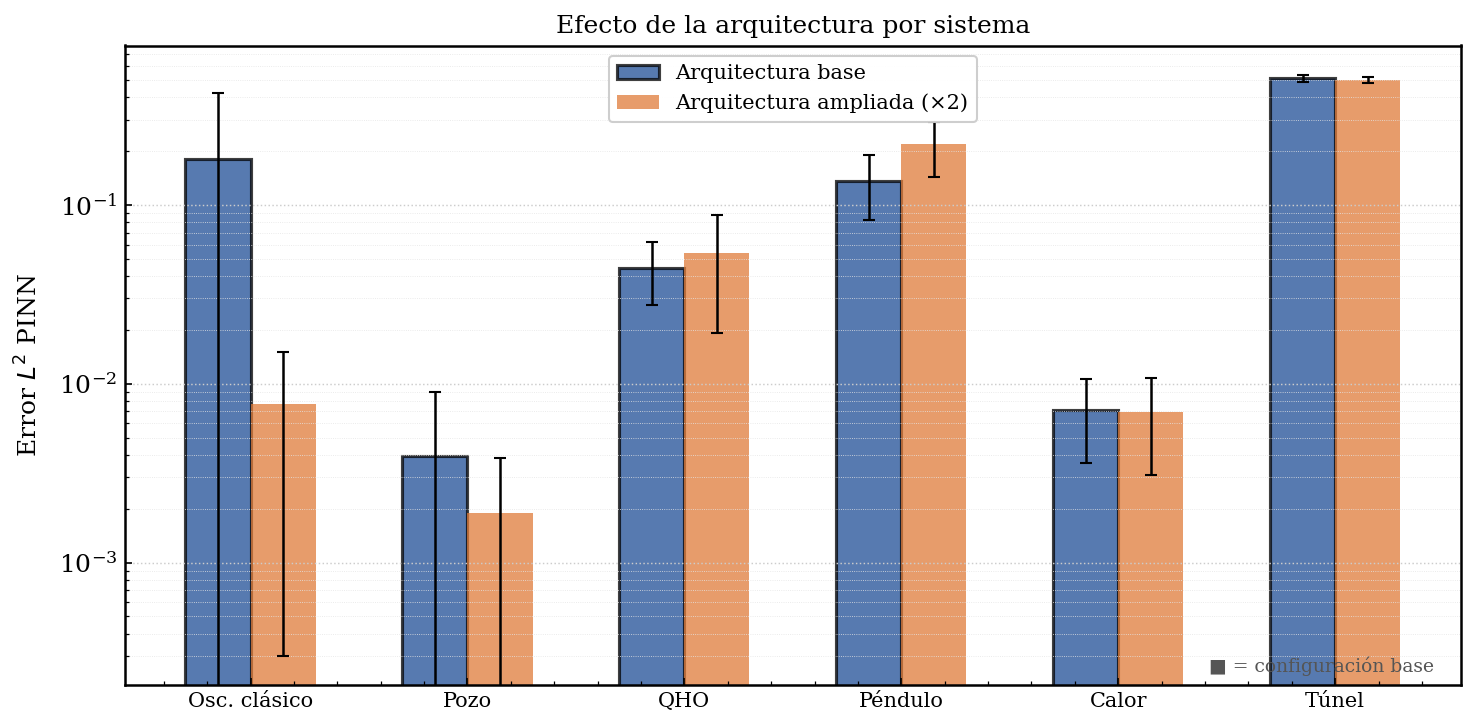

In [49]:
# ── Definir variantes de arquitectura por sistema ─────────────────────────
arch_variants = {
    "Osc. clásico": ["[32, 32, 32]",          "[64, 64, 64]"],
    "Pozo":         ["[32, 32, 32]",          "[64, 64, 64]"],
    "QHO":          ["[32, 32, 32]",          "[64, 64, 64]"],
    "Péndulo":      ["[32, 32, 32, 32, 32]",  "[64, 64, 64, 64, 64]"],
    "Calor":        ["[32, 32, 32]",          "[64, 64, 64]"],
    "Túnel":        ["[64, 64, 64, 64]",      "[128, 128, 128, 128]"],
}

rows_arch = []
for s in SISTEMAS_ORDER:
    base_arch, big_arch = arch_variants[s]
    mask = get_variant_mask(s, "hidden_layers", [base_arch, big_arch])
    for arch, grp in df_all[mask].groupby("hidden_layers"):
        label = "Base" if arch == base_arch else "Ampliada"
        rows_arch.append({
            "sistema":   s,
            "arch":      label,
            "arch_raw":  arch,
            "pinn_mean": grp["error_l2_pinn"].mean(),
            "pinn_std":  grp["error_l2_pinn"].std(),
            "nn_mean":   grp["error_l2_nn"].mean(),
            "n":         len(grp),
        })

df_arch = pd.DataFrame(rows_arch)

for s in SISTEMAS_ORDER:
    sub = df_arch[df_arch["sistema"] == s]
    print(f"{s:>14}: {len(sub)} variantes, "
          f"n por variante: {sub['n'].tolist()}")

# ── Preparar datos ────────────────────────────────────────────────────────
base_means, base_stds = [], []
big_means, big_stds = [], []
delta_pct_arch = []

for s in SISTEMAS_ORDER:
    sub = df_arch[df_arch["sistema"] == s]
    row_b = sub[sub["arch"] == "Base"]
    row_a = sub[sub["arch"] == "Ampliada"]

    vb = row_b["pinn_mean"].values[0] if len(row_b) else np.nan
    sb = row_b["pinn_std"].values[0]  if len(row_b) else 0
    va = row_a["pinn_mean"].values[0] if len(row_a) else np.nan
    sa = row_a["pinn_std"].values[0]  if len(row_a) else 0

    base_means.append(vb)
    base_stds.append(sb)
    big_means.append(va)
    big_stds.append(sa)
    delta_pct_arch.append((va - vb) / vb * 100)

# ── Gráfica A: Grouped bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(SISTEMAS_ORDER))
width = 0.3

bars1 = ax.bar(x - width/2, base_means, width, yerr=base_stds,
               color=C_PINN, alpha=0.75, label="Arquitectura base",
               capsize=3, error_kw={"linewidth": 1.2})
bars2 = ax.bar(x + width/2, big_means, width, yerr=big_stds,
               color=C_NN, alpha=0.75, label="Arquitectura ampliada (×2)",
               capsize=3, error_kw={"linewidth": 1.2})

for i in range(len(SISTEMAS_ORDER)):
    bars1[i].set_edgecolor("black")
    bars1[i].set_linewidth(1.5)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto de la arquitectura por sistema", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=10)
ax.grid(True, which="major", axis="y", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4,
        color="#e5e5e5", zorder=0)
ax.annotate("■ = configuración base", xy=(0.98, 0.02),
            xycoords="axes fraction", ha="right", fontsize=9,
            color="#555555")

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_architecture_absolute.png", dpi=300, bbox_inches="tight")
plt.show()

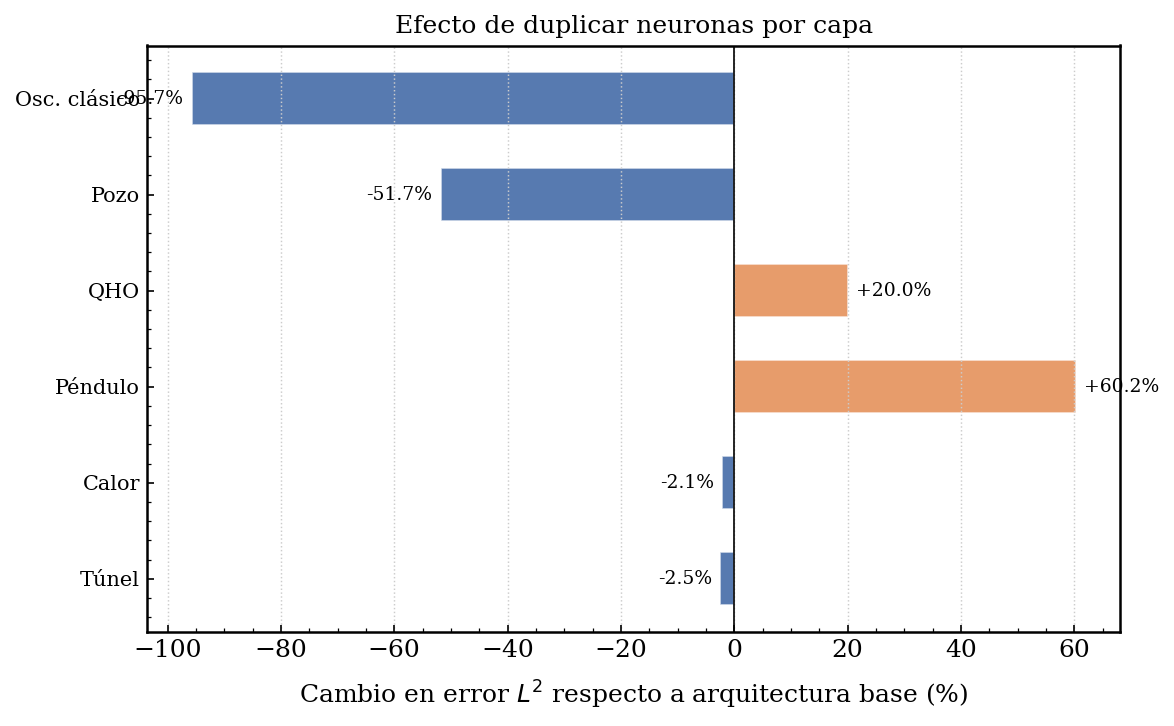


       Sistema           Base       Ampliada         Δ%        Mejor
────────────────────────────────────────────────────────────────────
  Osc. clásico     1.8111e-01     7.7053e-03      -95.7%     Ampliada
          Pozo     3.9263e-03     1.8952e-03      -51.7%     Ampliada
           QHO     4.4666e-02     5.3594e-02      +20.0%         Base
       Péndulo     1.3603e-01     2.1797e-01      +60.2%         Base
         Calor     7.0904e-03     6.9407e-03       -2.1%     Ampliada
         Túnel     5.1203e-01     4.9945e-01       -2.5%     Ampliada


In [23]:
# ── Gráfica B: Bar chart horizontal del % de cambio ──────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = np.arange(len(SISTEMAS_ORDER))
colors_arch = [C_PINN if d < 0 else C_NN for d in delta_pct_arch]

bars = ax.barh(y_pos, delta_pct_arch, color=colors_arch, alpha=0.75,
               edgecolor="white", linewidth=0.8, height=0.55)
ax.axvline(0, color="black", linewidth=0.8, zorder=2)

for i, (d, bar) in enumerate(zip(delta_pct_arch, bars)):
    ha = "left" if d >= 0 else "right"
    offset = 1.5 if d >= 0 else -1.5
    ax.text(d + offset, i, f"{d:+.1f}%", va="center", ha=ha, fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=10)
ax.set_xlabel("Cambio en error $L^2$ respecto a arquitectura base (%)", labelpad=8)
ax.set_title("Efecto de duplicar neuronas por capa", fontsize=12)
ax.invert_yaxis()
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7,
        color="#cccccc", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_architecture_delta.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Tabla numérica ────────────────────────────────────────────────────────
print(f"\n{'Sistema':>14} {'Base':>14} {'Ampliada':>14} {'Δ%':>10} {'Mejor':>12}")
print(f"{'─'*68}")
for i, s in enumerate(SISTEMAS_ORDER):
    vb = base_means[i]
    va = big_means[i]
    d = delta_pct_arch[i]
    mejor = "Base" if vb < va else "Ampliada" if va < vb else "—"
    print(f"{s:>14} {vb:>14.4e} {va:>14.4e} {d:>+10.1f}% {mejor:>12}")

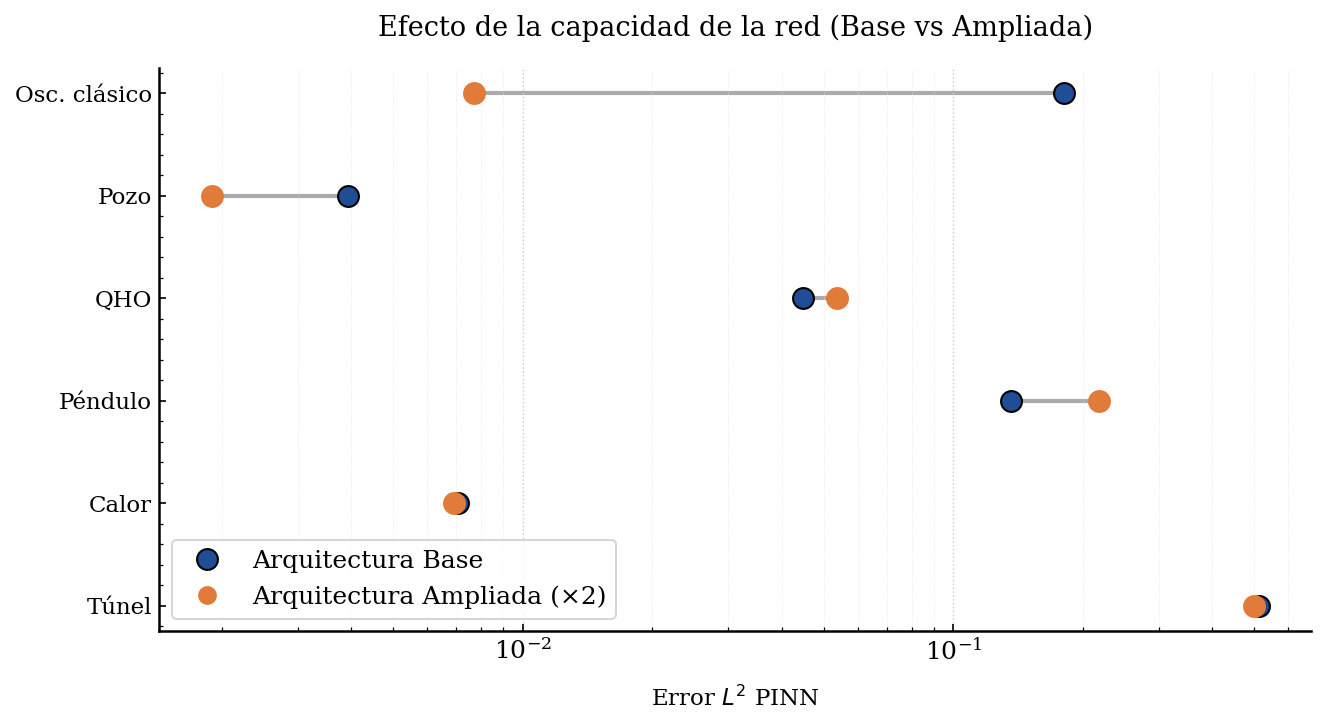

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Asumo que base_means y big_means ya están calculados con tu código

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(SISTEMAS_ORDER))

for i, s in enumerate(SISTEMAS_ORDER):
    vb = base_means[i]
    va = big_means[i]
    
    # Dibujar la línea conectora (la barra de la mancuerna)
    ax.plot([vb, va], [i, i], color="#aaaaaa", linewidth=2, zorder=1)
    
    # Dibujar los puntos (los discos de la mancuerna)
    # Borde negro para la Base, sin borde para la Ampliada
    ax.plot(vb, i, "o", color=C_PINN, markersize=10, markeredgecolor="black", zorder=3)
    ax.plot(va, i, "o", color=C_NN, markersize=10, zorder=3)

ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(SISTEMAS_ORDER, fontsize=11)
ax.set_xlabel("Error $L^2$ PINN", labelpad=10, fontsize=11)
ax.set_title("Efecto de la capacidad de la red (Base vs Ampliada)", fontsize=13, pad=15)
ax.invert_yaxis() # Para que el primer sistema quede arriba

# Limpieza y cuadrícula
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="major", axis="x", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", axis="x", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

# Leyenda
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_PINN, markersize=10, markeredgecolor="black", label="Arquitectura Base"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=C_NN, markersize=10, label="Arquitectura Ampliada (×2)")
]
ax.legend(handles=legend_elements, loc="lower left", frameon=True, edgecolor="#cccccc")

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje5_architecture_dumbbell.png", dpi=300, bbox_inches="tight")
plt.show()

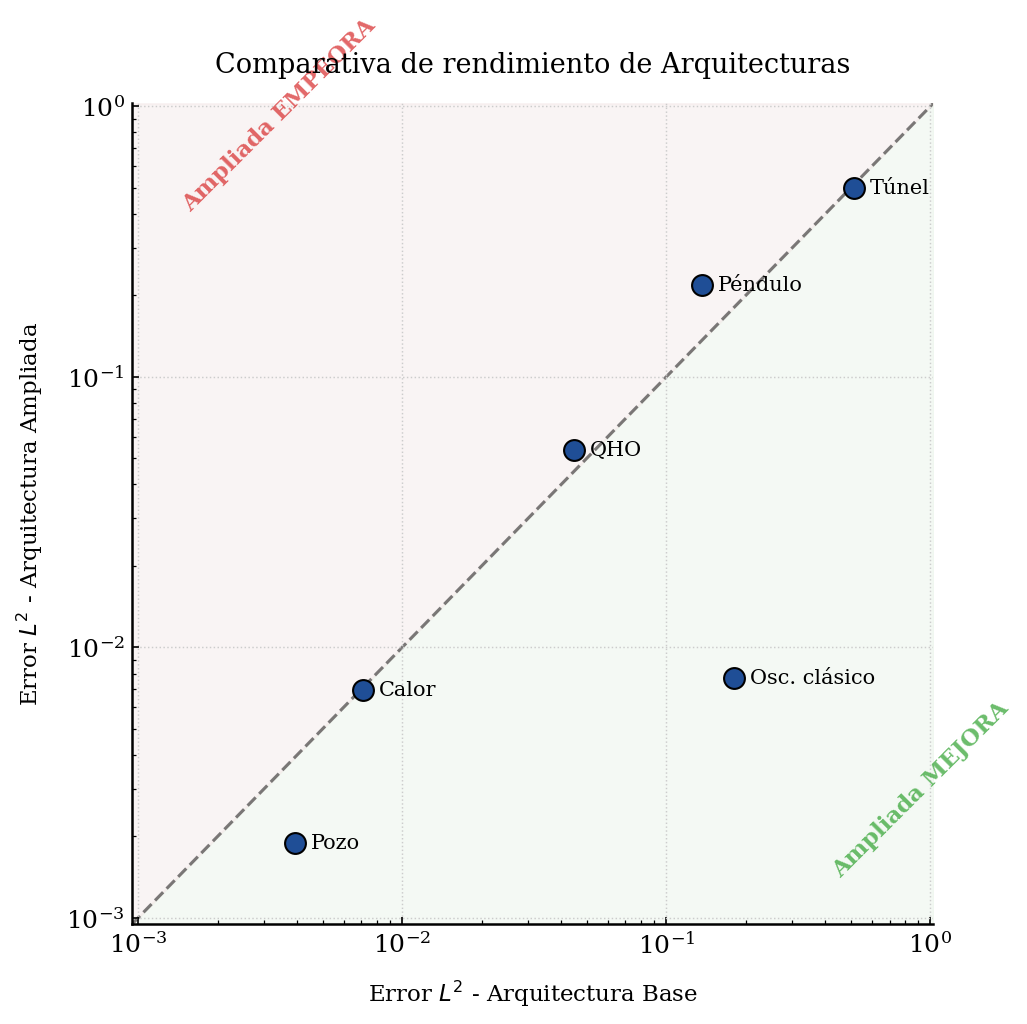

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7)) # Cuadrado perfecto para la diagonal

# Plotear los puntos de cada sistema
for i, s in enumerate(SISTEMAS_ORDER):
    vb = base_means[i]
    va = big_means[i]
    
    # Punto representativo
    ax.scatter(vb, va, color=C_PINN, edgecolor="black", s=100, zorder=3)
    
    # Añadir el nombre del sistema al lado del punto para saber cuál es cuál
    ax.text(vb * 1.15, va, s, fontsize=10, verticalalignment='center', zorder=4)

# Configurar la escala logarítmica y límites cuadrados
ax.set_xscale("log")
ax.set_yscale("log")

# Buscar mínimos y máximos globales para trazar la diagonal correctamente
val_min = min(min(base_means), min(big_means)) * 0.5
val_max = max(max(base_means), max(big_means)) * 2.0
ax.set_xlim(val_min, val_max)
ax.set_ylim(val_min, val_max)

# ── La línea diagonal y=x (Igualdad de error) ──
ax.plot([val_min, val_max], [val_min, val_max], "k--", alpha=0.5, zorder=1)

# Sombrear las áreas para que la lectura sea a prueba de tontos
ax.fill_between([val_min, val_max], [val_min, val_max], val_min, color="#eaf5ea", alpha=0.5, zorder=0) # Zona verde (Mejora)
ax.fill_between([val_min, val_max], [val_min, val_max], val_max, color="#f5eaea", alpha=0.5, zorder=0) # Zona roja (Empeora)

# Textos en las zonas sombreadas
ax.text(val_max * 0.4, val_min * 1.5, "Ampliada MEJORA", color="#2ca02c", fontsize=11, weight="bold", alpha=0.7, rotation=45)
ax.text(val_min * 1.5, val_max * 0.4, "Ampliada EMPEORA", color="#d62728", fontsize=11, weight="bold", alpha=0.7, rotation=45)

ax.set_xlabel("Error $L^2$ - Arquitectura Base", fontsize=11, labelpad=10)
ax.set_ylabel("Error $L^2$ - Arquitectura Ampliada", fontsize=11, labelpad=10)
ax.set_title("Comparativa de rendimiento de Arquitecturas", fontsize=13, pad=15)

# Limpieza
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)

plt.tight_layout()
# plt.savefig(FIGS_DIR / "eje5_architecture_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# ── Tabla resumen global ──────────────────────────────────────────────────

resumen_global = []

# ── Helper ────────────────────────────────────────────────────────────────
def add_eje(eje_label, col, vals, label_map=None):
    """Añade filas al resumen para un eje binario."""
    for s in SISTEMAS_ORDER:
        mask = get_variant_mask(s, col, vals)
        for val, grp in df_all[mask].groupby(col):
            label = label_map[val] if label_map else str(val)
            is_base = (val == BASE_CONFIGS[s].get(col))
            resumen_global.append({
                "Eje":       eje_label,
                "Sistema":   s,
                "Variante":  label,
                "Base":      "✓" if is_base else "",
                "PINN mean": grp["error_l2_pinn"].mean(),
                "PINN std":  grp["error_l2_pinn"].std(),
                "NN mean":   grp["error_l2_nn"].mean(),
                "N":         len(grp),
            })

# ── Eje 1: Optimizador ───────────────────────────────────────────────────
add_eje("1·Optimizador", "optimizer", ["adam", "adam+lbfgs"],
        {"adam": "Adam", "adam+lbfgs": "Adam+LBFGS"})

# ── Eje 2: Learning rate ─────────────────────────────────────────────────
add_eje("2·Learning rate", "lr", [0.001, 0.01],
        {0.001: "lr=0.001", 0.01: "lr=0.01"})

# ── Eje 3: Pesos dinámicos ───────────────────────────────────────────────
add_eje("3·Pesos dinámicos", "use_dynamic_weights", [False, True],
        {False: "Fijos", True: "Dinámicos"})

# ── Eje 4: Sampler ───────────────────────────────────────────────────────
add_eje("4·Sampler", "sampler", ["lhs", "grid"],
        {"lhs": "LHS", "grid": "Grid"})

# ── Eje 5: Arquitectura (requiere tratamiento especial) ──────────────────
for s in SISTEMAS_ORDER:
    base_arch, big_arch = arch_variants[s]
    mask = get_variant_mask(s, "hidden_layers", [base_arch, big_arch])
    for arch, grp in df_all[mask].groupby("hidden_layers"):
        label = "Base" if arch == base_arch else "Ampliada (×2)"
        is_base = (arch == base_arch)
        resumen_global.append({
            "Eje":       "5·Arquitectura",
            "Sistema":   s,
            "Variante":  label,
            "Base":      "✓" if is_base else "",
            "PINN mean": grp["error_l2_pinn"].mean(),
            "PINN std":  grp["error_l2_pinn"].std(),
            "NN mean":   grp["error_l2_nn"].mean(),
            "N":         len(grp),
        })

# ── Formatear y mostrar ──────────────────────────────────────────────────
df_resumen = pd.DataFrame(resumen_global)

print(f"\n{'═'*120}")
print(f"{'EJE':<20} {'SISTEMA':<16} {'VARIANTE':<18} {'BASE':>4} "
      f"{'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} {'N':>4}")
print(f"{'─'*120}")

eje_actual = None
for _, row in df_resumen.iterrows():
    if row["Eje"] != eje_actual:
        if eje_actual is not None:
            print(f"{'─'*120}")
        eje_actual = row["Eje"]
    print(f"{row['Eje']:<20} {row['Sistema']:<16} {row['Variante']:<18} "
          f"{row['Base']:>4} {row['PINN mean']:>12.4e} {row['PINN std']:>10.4e} "
          f"{row['NN mean']:>12.4e} {int(row['N']):>4}")

print(f"{'═'*120}")

# ── Tabla de deltas % ────────────────────────────────────────────────────
print(f"\n\n{'═'*90}")
print(f"{'EJE':<20} {'SISTEMA':<16} {'BASE →':>12} {'VARIANTE →':>12} {'Δ%':>10}")
print(f"{'─'*90}")

ejes_delta = [
    ("1·Optimizador",     "optimizer",           ["adam", "adam+lbfgs"]),
    ("2·Learning rate",   "lr",                  [0.001, 0.01]),
    ("3·Pesos dinámicos", "use_dynamic_weights", [False, True]),
    ("4·Sampler",         "sampler",             ["lhs", "grid"]),
]

for eje_label, col, vals in ejes_delta:
    for s in SISTEMAS_ORDER:
        base_val = BASE_CONFIGS[s].get(col)
        alt_val = [v for v in vals if v != base_val][0]
        mask_base = get_variant_mask(s, col, [base_val])
        mask_alt  = get_variant_mask(s, col, [alt_val])
        vb = df_all[mask_base]["error_l2_pinn"].mean()
        va = df_all[mask_alt]["error_l2_pinn"].mean()
        delta = (va - vb) / vb * 100
        print(f"{eje_label:<20} {s:<16} {vb:>12.4e} {va:>12.4e} {delta:>+10.1f}%")
    print(f"{'─'*90}")

# Arquitectura aparte
for s in SISTEMAS_ORDER:
    base_arch, big_arch = arch_variants[s]
    mask_b = get_variant_mask(s, "hidden_layers", [base_arch])
    mask_a = get_variant_mask(s, "hidden_layers", [big_arch])
    vb = df_all[mask_b]["error_l2_pinn"].mean()
    va = df_all[mask_a]["error_l2_pinn"].mean()
    delta = (va - vb) / vb * 100
    print(f"{'5·Arquitectura':<20} {s:<16} {vb:>12.4e} {va:>12.4e} {delta:>+10.1f}%")

print(f"{'═'*90}")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
EJE                  SISTEMA          VARIANTE           BASE      PINN L2   PINN std        NN L2    N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1·Optimizador        Osc. clásico     Adam                  ✓   1.8111e-01 2.4130e-01   1.7228e+00   10
1·Optimizador        Osc. clásico     Adam+LBFGS                1.0619e-03 1.0651e-03   1.8662e+00   10
1·Optimizador        Pozo             Adam                  ✓   3.9263e-03 5.0726e-03   1.9231e+00   10
1·Optimizador        Pozo             Adam+LBFGS                1.0304e-04 4.1793e-05   2.0811e+00   10
1·Optimizador        QHO              Adam                  ✓   4.4666e-02 1.7125e-02   8.5690e-01   10
1·Optimizador        QHO              Adam+LBFGS                1.7897e-03 4.5678e-04   1.0481e+00   11
1·Optimizador        Péndulo 

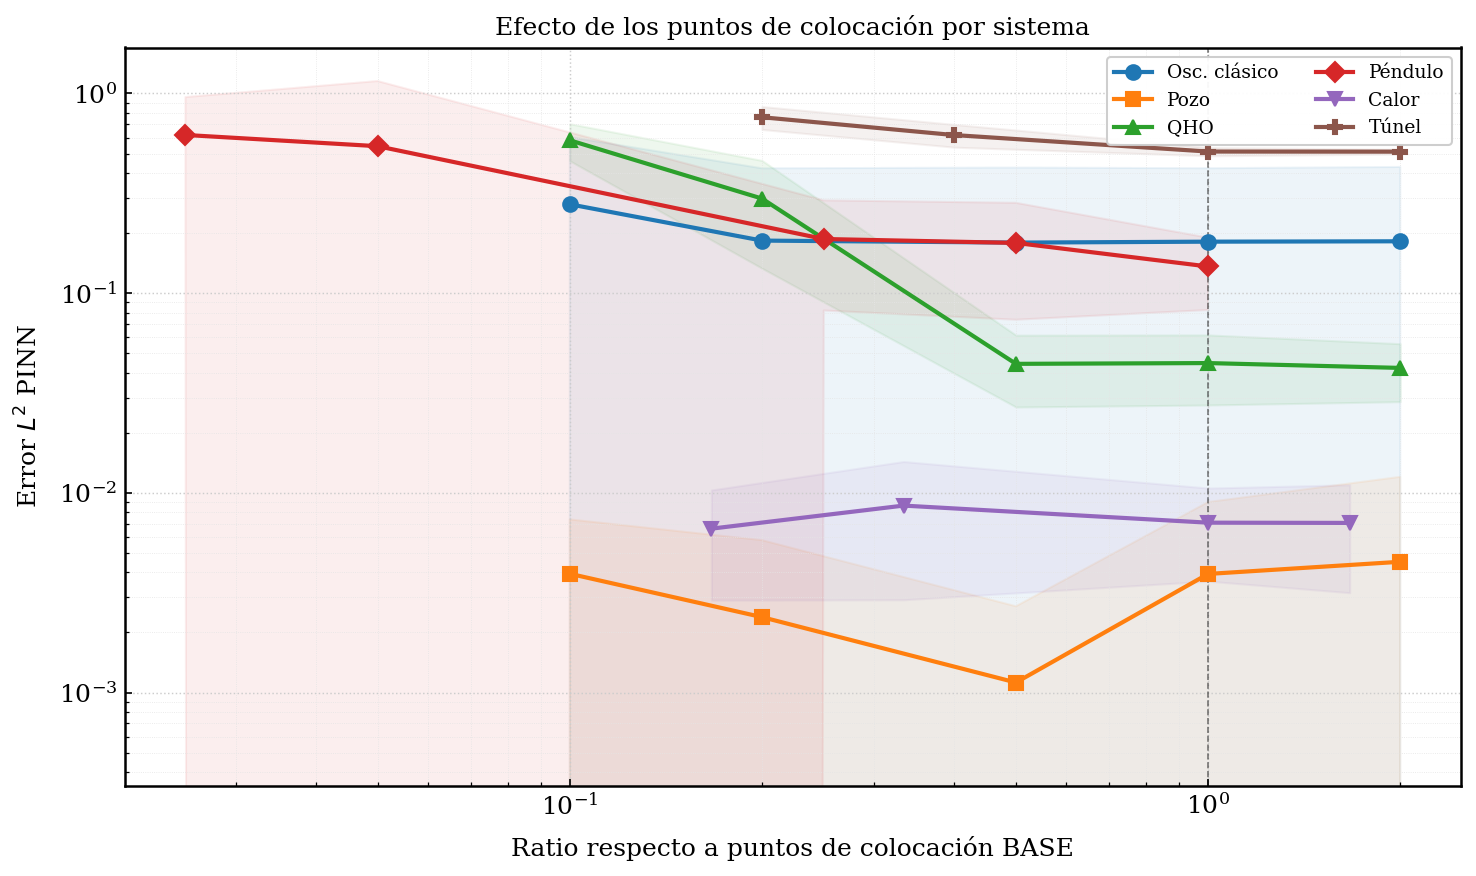

In [66]:
# ── Gráfica: Puntos de colocación (ratio normalizado) ─────────────────────

col_base = {
    "Osc. clásico": 500, "Pozo": 500, "QHO": 500,
    "Péndulo": 2000, "Calor": 3000, "Túnel": 5000,
}

col_configs = {
    "Osc. clásico": ("num_domain_points", [50, 100, 250, 500, 1000]),
    "Pozo":         ("num_domain_points", [50, 100, 250, 500, 1000]),
    "QHO":          ("num_domain_points", [50, 100, 250, 500, 1000]),
    "Péndulo":      ("num_domain_points", [50, 100, 500, 1000, 2000]),
    "Calor":        ("num_collocation",   [500, 1000, 3000, 5000]),
    "Túnel":        ("num_collocation",   [1000, 2000, 5000, 10000]),
}

COLORS_SIS = {
    "Osc. clásico": "#1f77b4",
    "Pozo":         "#ff7f0e",
    "QHO":          "#2ca02c",
    "Péndulo":      "#d62728",
    "Calor":        "#9467bd",
    "Túnel":        "#8c564b",
}
MARKERS_SIS = {
    "Osc. clásico": "o",
    "Pozo":         "s",
    "QHO":          "^",
    "Péndulo":      "D",
    "Calor":        "v",
    "Túnel":        "P",
}

fig, ax = plt.subplots(figsize=(10, 6))

for s in SISTEMAS_ORDER:
    col_name, vals = col_configs[s]
    mask = get_variant_mask(s, col_name, vals)
    sub = df_all[mask].copy()
    sub["ratio"] = sub[col_name] / col_base[s]

    agg = sub.groupby("ratio").agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg["ratio"], agg["pinn_mean"],
            marker=MARKERS_SIS[s], color=COLORS_SIS[s],
            linewidth=2, markersize=7, label=s, zorder=3)
    ax.fill_between(agg["ratio"],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.08, zorder=1)

ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Ratio respecto a puntos de colocación BASE", labelpad=8)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto de los puntos de colocación por sistema", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=9,
          ncol=2, loc="upper right")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_collocation_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

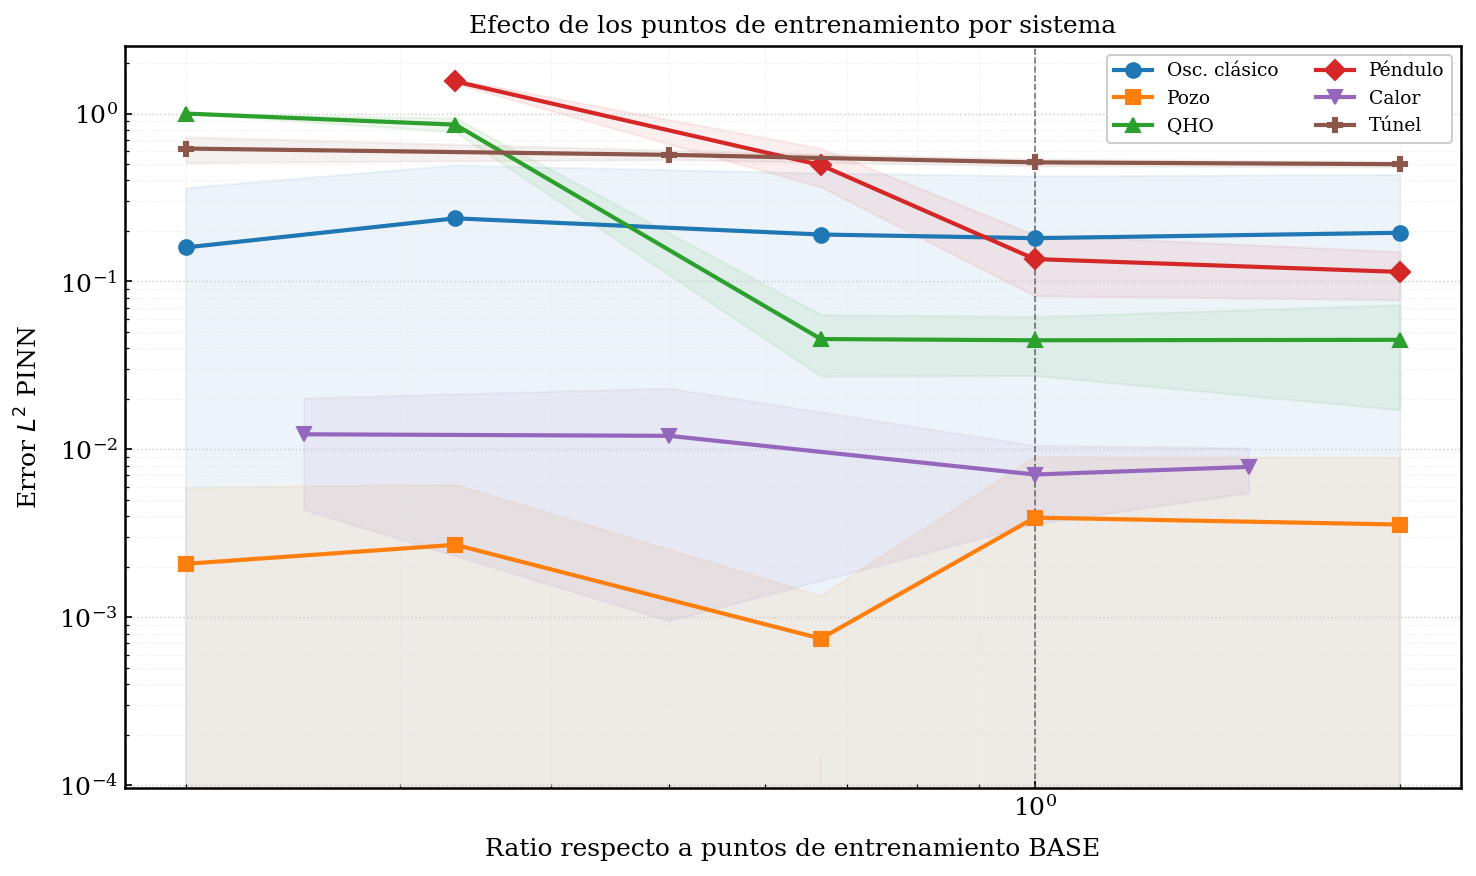

In [67]:
# ── Gráfica: Puntos de entrenamiento (ratio normalizado) ──────────────────

train_configs = {
    "Osc. clásico": [3, 5, 10, 15, 30],
    "Pozo":         [3, 5, 10, 15, 30],
    "QHO":          [3, 5, 10, 15, 30],
    "Péndulo":      [5, 10, 15, 30],
    "Calor":        [5, 10, 20, 30],
    "Túnel":        [20, 50, 100, 200],
}

train_base = {
    "Osc. clásico": 15, "Pozo": 15, "QHO": 15,
    "Péndulo": 15, "Calor": 20, "Túnel": 100,
}

fig, ax = plt.subplots(figsize=(10, 6))

for s in SISTEMAS_ORDER:
    vals = train_configs[s]
    mask = get_variant_mask(s, "num_train_points", vals)
    sub = df_all[mask].copy()
    sub["ratio"] = sub["num_train_points"] / train_base[s]

    agg = sub.groupby("ratio").agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg["ratio"], agg["pinn_mean"],
            marker=MARKERS_SIS[s], color=COLORS_SIS[s],
            linewidth=2, markersize=7, label=s, zorder=3)
    ax.fill_between(agg["ratio"],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.08, zorder=1)

ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Ratio respecto a puntos de entrenamiento BASE", labelpad=8)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto de los puntos de entrenamiento por sistema", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=9,
          ncol=2, loc="upper right")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_train_points_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

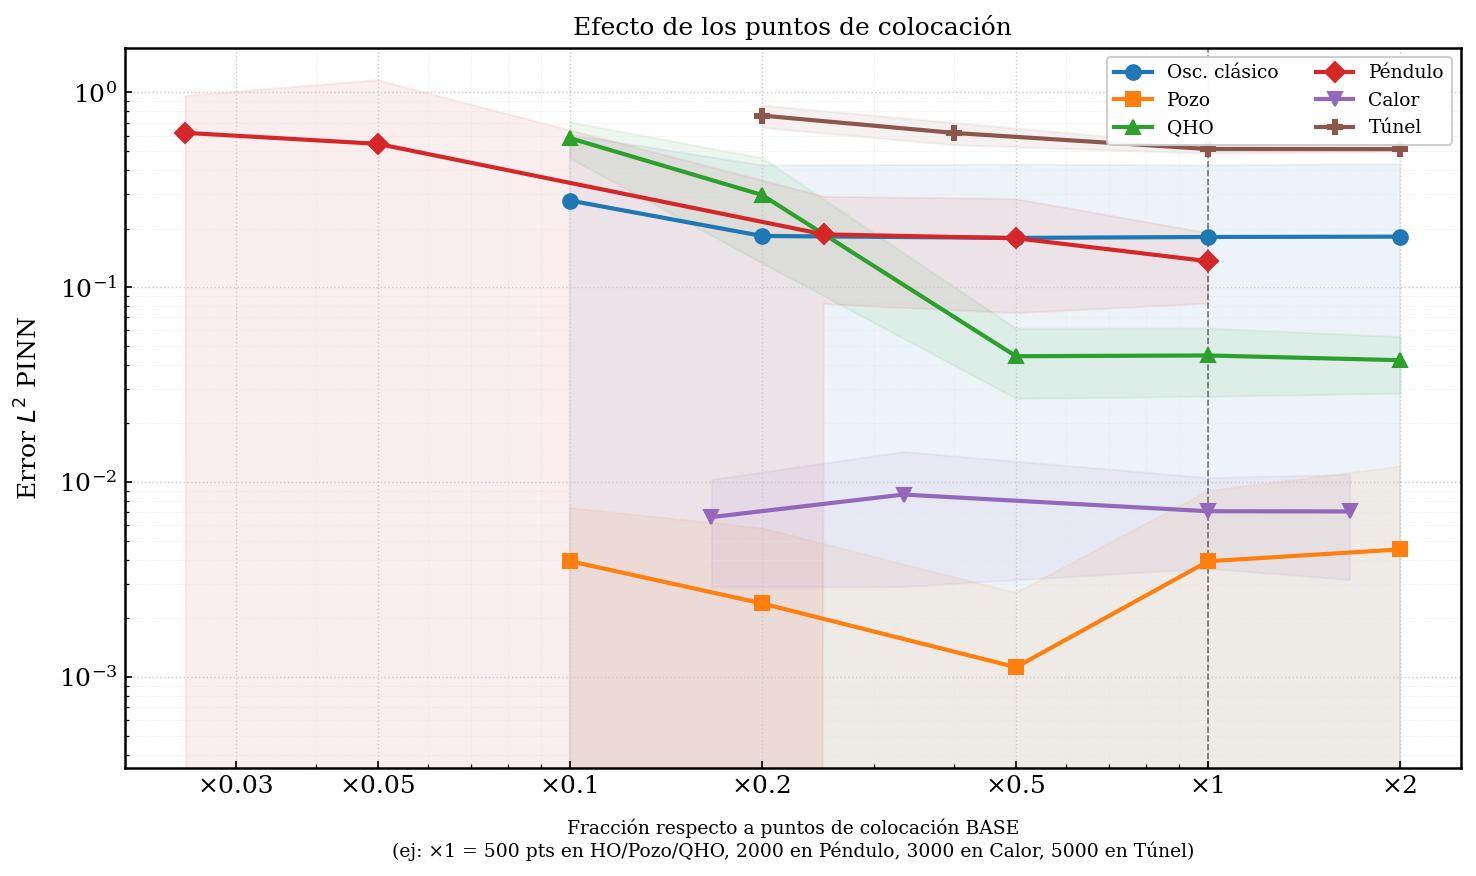

In [68]:
# ══════════════════════════════════════════════════════════════════════════
# PUNTOS DE COLOCACIÓN
# ══════════════════════════════════════════════════════════════════════════

# ── Opción A: Líneas superpuestas con doble eje X ─────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

for s in SISTEMAS_ORDER:
    col_name, vals = col_configs[s]
    mask = get_variant_mask(s, col_name, vals)
    sub = df_all[mask].copy()
    sub["ratio"] = sub[col_name] / col_base[s]

    agg = sub.groupby("ratio").agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg["ratio"], agg["pinn_mean"],
            marker=MARKERS_SIS[s], color=COLORS_SIS[s],
            linewidth=2, markersize=7, label=s, zorder=3)
    ax.fill_between(agg["ratio"],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.08, zorder=1)

ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
ax.set_xscale("log")
ax.set_yscale("log")

# Tick labels con formato ×
ratio_ticks = [0.03, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
ax.set_xticks(ratio_ticks)
ax.set_xticklabels([f"×{r:g}" for r in ratio_ticks])
ax.set_xlabel("Fracción respecto a puntos de colocación BASE\n"
              "(ej: ×1 = 500 pts en HO/Pozo/QHO, 2000 en Péndulo, "
              "3000 en Calor, 5000 en Túnel)", labelpad=10, fontsize=9)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto de los puntos de colocación", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=9,
          ncol=2, loc="upper right")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_collocation_ratio_A.png", dpi=300, bbox_inches="tight")
plt.show()

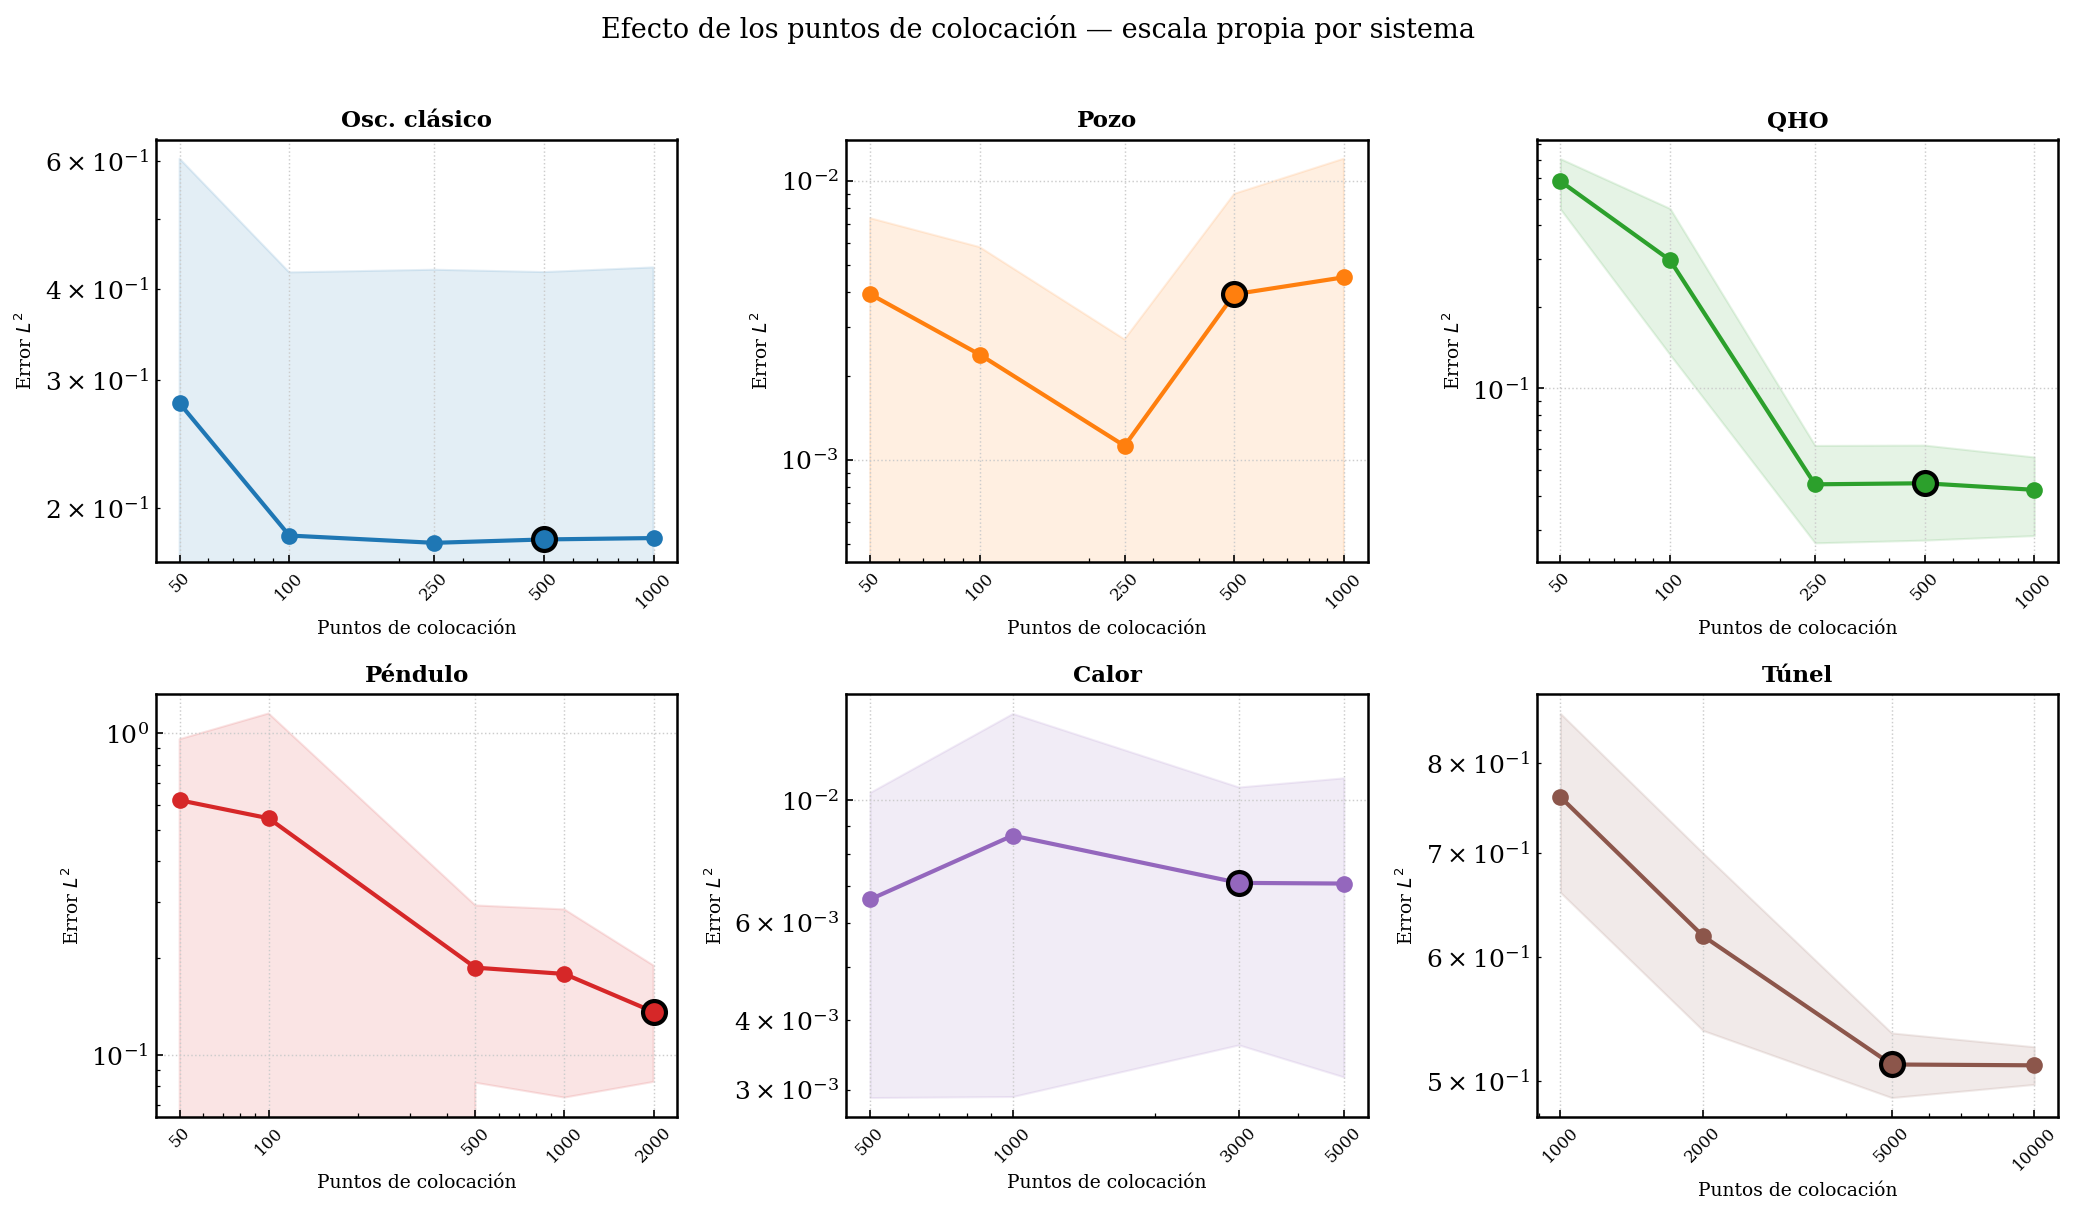

In [69]:
# ── Opción B: Panel 2×3 con valores absolutos ────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, s in enumerate(SISTEMAS_ORDER):
    ax = axes[i]
    col_name, vals = col_configs[s]
    mask = get_variant_mask(s, col_name, vals)
    sub = df_all[mask].copy()

    agg = sub.groupby(col_name).agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg[col_name], agg["pinn_mean"],
            marker="o", color=COLORS_SIS[s],
            linewidth=2, markersize=7, zorder=3)
    ax.fill_between(agg[col_name],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.12, zorder=1)

    # Marcar BASE
    base_val = col_base[s]
    base_row = agg[agg[col_name] == base_val]
    if len(base_row):
        ax.plot(base_val, base_row["pinn_mean"].values[0],
                marker="o", color=COLORS_SIS[s], markersize=11,
                markeredgecolor="black", markeredgewidth=2, zorder=4)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(vals)
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.set_title(s, fontsize=11, fontweight="bold")
    ax.set_ylabel("Error $L^2$", fontsize=9)
    ax.set_xlabel("Puntos de colocación", fontsize=9)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7,
            color="#cccccc", zorder=0)

plt.suptitle("Efecto de los puntos de colocación — escala propia por sistema",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_collocation_panels_B.png", dpi=300, bbox_inches="tight")
plt.show()

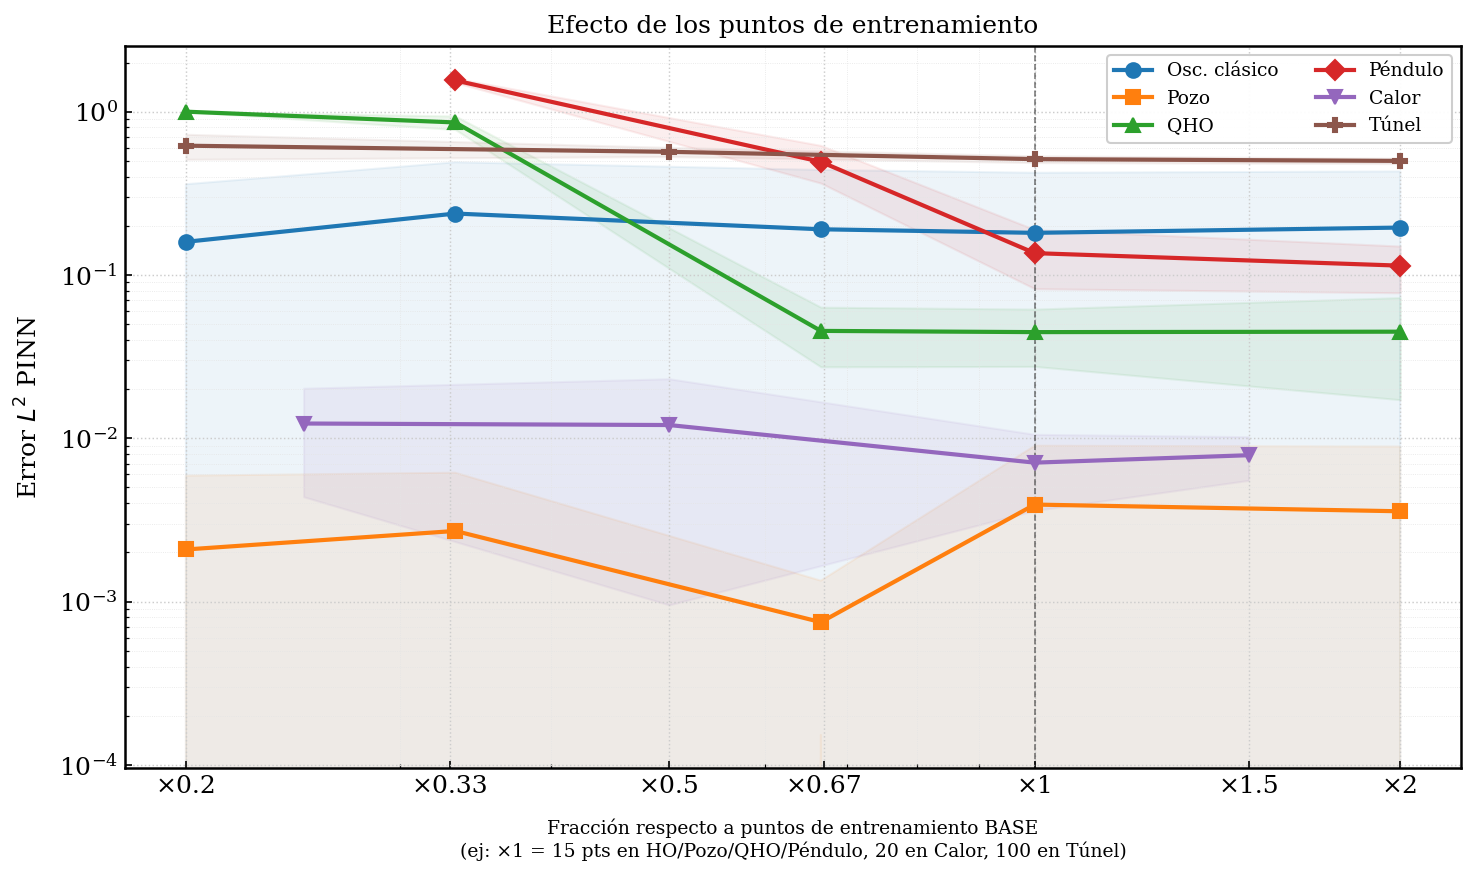

In [70]:
# ══════════════════════════════════════════════════════════════════════════
# PUNTOS DE ENTRENAMIENTO
# ══════════════════════════════════════════════════════════════════════════

# ── Opción A: Líneas superpuestas con ratio ──────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

for s in SISTEMAS_ORDER:
    vals = train_configs[s]
    mask = get_variant_mask(s, "num_train_points", vals)
    sub = df_all[mask].copy()
    sub["ratio"] = sub["num_train_points"] / train_base[s]

    agg = sub.groupby("ratio").agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg["ratio"], agg["pinn_mean"],
            marker=MARKERS_SIS[s], color=COLORS_SIS[s],
            linewidth=2, markersize=7, label=s, zorder=3)
    ax.fill_between(agg["ratio"],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.08, zorder=1)

ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)
ax.set_xscale("log")
ax.set_yscale("log")

ratio_ticks_train = [0.2, 0.33, 0.5, 0.67, 1.0, 1.5, 2.0]
ax.set_xticks(ratio_ticks_train)
ax.set_xticklabels([f"×{r:g}" for r in ratio_ticks_train])
ax.set_xlabel("Fracción respecto a puntos de entrenamiento BASE\n"
              "(ej: ×1 = 15 pts en HO/Pozo/QHO/Péndulo, "
              "20 en Calor, 100 en Túnel)", labelpad=10, fontsize=9)
ax.set_ylabel("Error $L^2$ PINN", labelpad=8)
ax.set_title("Efecto de los puntos de entrenamiento", fontsize=12)
ax.legend(frameon=True, framealpha=0.95, edgecolor="#cccccc", fontsize=9,
          ncol=2, loc="upper right")
ax.grid(True, which="major", linestyle=":", linewidth=0.7, color="#cccccc", zorder=0)
ax.grid(True, which="minor", linestyle=":", linewidth=0.4, color="#e5e5e5", zorder=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_train_points_ratio_A.png", dpi=300, bbox_inches="tight")
plt.show()

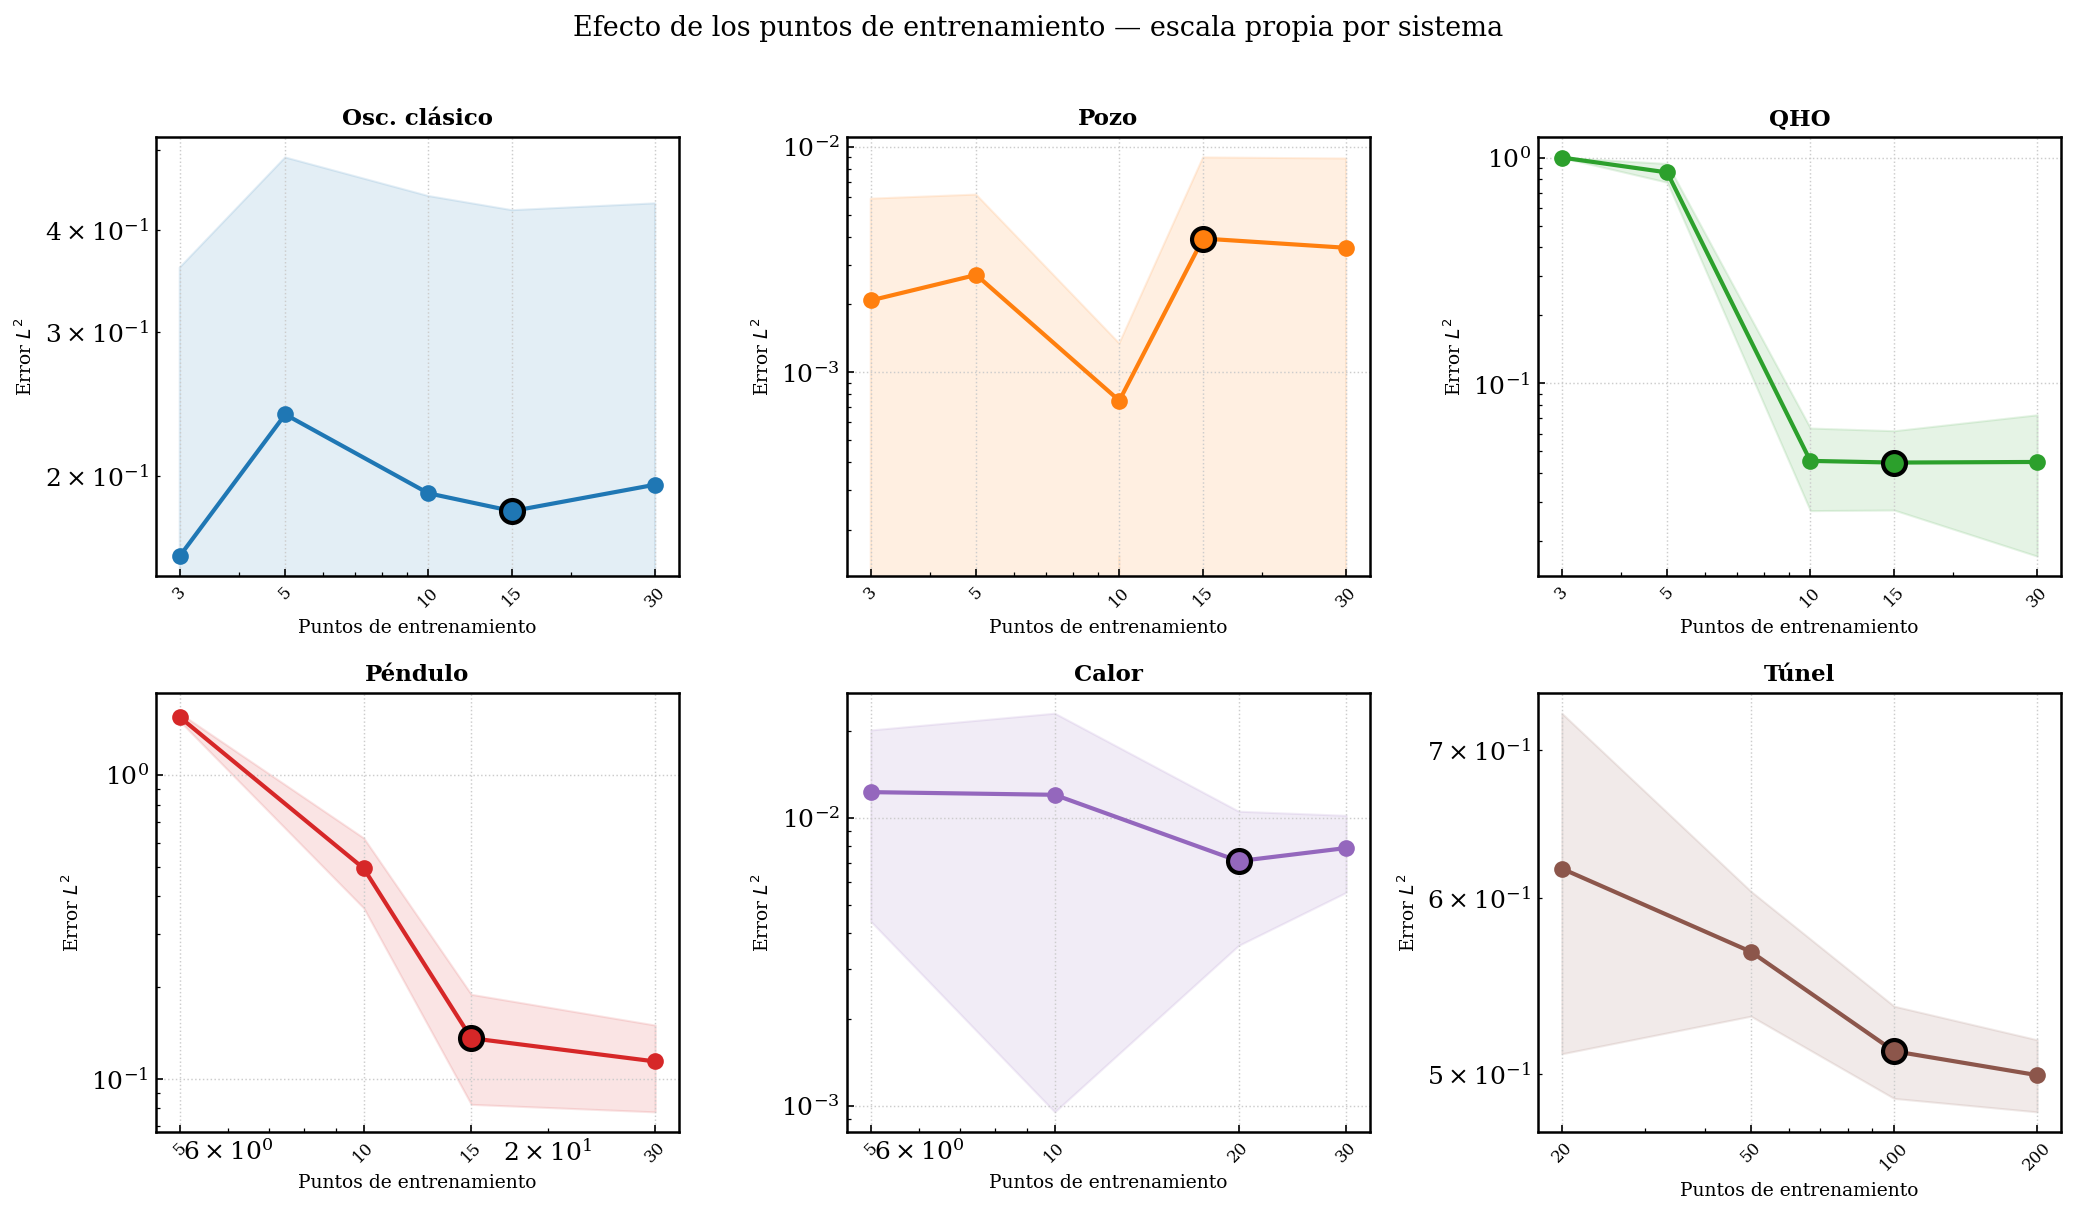

In [72]:
# ── Opción B: Panel 2×3 con valores absolutos ────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, s in enumerate(SISTEMAS_ORDER):
    ax = axes[i]
    vals = train_configs[s]
    mask = get_variant_mask(s, "num_train_points", vals)
    sub = df_all[mask].copy()

    agg = sub.groupby("num_train_points").agg(
        pinn_mean=("error_l2_pinn", "mean"),
        pinn_std =("error_l2_pinn", "std"),
    ).reset_index()

    ax.plot(agg["num_train_points"], agg["pinn_mean"],
            marker="o", color=COLORS_SIS[s],
            linewidth=2, markersize=7, zorder=3)
    ax.fill_between(agg["num_train_points"],
        agg["pinn_mean"] - agg["pinn_std"],
        agg["pinn_mean"] + agg["pinn_std"],
        color=COLORS_SIS[s], alpha=0.12, zorder=1)

    # Marcar BASE
    bval = train_base[s]
    base_row = agg[agg["num_train_points"] == bval]
    if len(base_row):
        ax.plot(bval, base_row["pinn_mean"].values[0],
                marker="o", color=COLORS_SIS[s], markersize=11,
                markeredgecolor="black", markeredgewidth=2, zorder=4)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(vals)
    ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.set_title(s, fontsize=11, fontweight="bold")
    ax.set_ylabel("Error $L^2$", fontsize=9)
    ax.set_xlabel("Puntos de entrenamiento", fontsize=9)
    ax.grid(True, which="major", linestyle=":", linewidth=0.7,
            color="#cccccc", zorder=0)

plt.suptitle("Efecto de los puntos de entrenamiento — escala propia por sistema",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR / "eje_train_points_panels_B.png", dpi=300, bbox_inches="tight")
plt.show()

In [65]:
# ── Puntos de colocación — ratio normalizado ──────────────────────────────

col_configs = {
    "Osc. clásico": ("num_domain_points", [50, 100, 250, 500, 1000]),
    "Pozo":         ("num_domain_points", [50, 100, 250, 500, 1000]),
    "QHO":          ("num_domain_points", [50, 100, 250, 500, 1000]),
    "Péndulo":      ("num_domain_points", [50, 100, 500, 1000, 2000]),
    "Calor":        ("num_collocation",   [500, 1000, 3000, 5000]),
    "Túnel":        ("num_collocation",   [1000, 2000, 5000, 10000]),
}

col_base = {
    "Osc. clásico": 500, "Pozo": 500, "QHO": 500,
    "Péndulo": 2000, "Calor": 3000, "Túnel": 5000,
}

print(f"{'Sistema':<16} {'Ratio':>8} {'Puntos':>8} {'PINN L2':>12} {'PINN std':>10} {'N':>4}")
print(f"{'─'*62}")
for s in SISTEMAS_ORDER:
    col_name, vals = col_configs[s]
    mask = get_variant_mask(s, col_name, vals)
    for val, grp in df_all[mask].groupby(col_name):
        ratio = val / col_base[s]
        print(f"{s:<16} {ratio:>8.2f} {int(val):>8} "
              f"{grp['error_l2_pinn'].mean():>12.4e} "
              f"{grp['error_l2_pinn'].std():>10.4e} {len(grp):>4}")
    print()

# ── Puntos de entrenamiento — ratio normalizado ──────────────────────────

train_configs = {
    "Osc. clásico": [3, 5, 10, 15, 30],
    "Pozo":         [3, 5, 10, 15, 30],
    "QHO":          [3, 5, 10, 15, 30],
    "Péndulo":      [5, 10, 15, 30],
    "Calor":        [5, 10, 20, 30],
    "Túnel":        [20, 50, 100, 200],
}

train_base = {
    "Osc. clásico": 15, "Pozo": 15, "QHO": 15,
    "Péndulo": 15, "Calor": 20, "Túnel": 100,
}

print(f"\n{'Sistema':<16} {'Ratio':>8} {'Puntos':>8} {'PINN L2':>12} {'PINN std':>10} {'N':>4}")
print(f"{'─'*62}")
for s in SISTEMAS_ORDER:
    vals = train_configs[s]
    mask = get_variant_mask(s, "num_train_points", vals)
    for val, grp in df_all[mask].groupby("num_train_points"):
        ratio = val / train_base[s]
        print(f"{s:<16} {ratio:>8.2f} {int(val):>8} "
              f"{grp['error_l2_pinn'].mean():>12.4e} "
              f"{grp['error_l2_pinn'].std():>10.4e} {len(grp):>4}")
    print()

Sistema             Ratio   Puntos      PINN L2   PINN std    N
──────────────────────────────────────────────────────────────
Osc. clásico         0.10       50   2.7872e-01 3.2621e-01   10
Osc. clásico         0.20      100   1.8337e-01 2.3867e-01   10
Osc. clásico         0.50      250   1.7918e-01 2.4639e-01   10
Osc. clásico         1.00      500   1.8111e-01 2.4130e-01   10
Osc. clásico         2.00     1000   1.8191e-01 2.4678e-01   10

Pozo                 0.10       50   3.9336e-03 3.4298e-03   10
Pozo                 0.20      100   2.3864e-03 3.4108e-03   10
Pozo                 0.50      250   1.1225e-03 1.5822e-03   10
Pozo                 1.00      500   3.9263e-03 5.0726e-03   10
Pozo                 2.00     1000   4.5168e-03 7.5129e-03   10

QHO                  0.10       50   5.8292e-01 1.2288e-01   11
QHO                  0.20      100   2.9777e-01 1.6441e-01   10
QHO                  0.50      250   4.4268e-02 1.7357e-02   10
QHO                  1.00      500   4.

In [75]:
# ══════════════════════════════════════════════════════════════════════════
# DATOS PARA SECCIÓN 6.5 — Robustez e identificación de parámetros
# ══════════════════════════════════════════════════════════════════════════

records_calor = []

for fpath in sorted(RESULTS_DIR.glob("heat_inverse/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_calor.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_collocation":     cfg["num_collocation"],
        "num_train_points":    cfg["num_train_points"],
        "noise_std":           cfg["noise_std"],
        "sampler":             cfg["sampler"],
        "warmup_epochs":       cfg["warmup_epochs"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "alpha_true":          cfg["alpha_true"],
        "alpha_init":          cfg["alpha_init"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2_mean"],
        "time_pinn":           res["pinn"]["time_s"],
        "alpha_learned":       res["pinn"]["alpha_learned"],
        "error_rel_alpha":     res["pinn"]["error_relativo_alpha"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2_mean"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados Crank-Nicolson ──────────────────────────────
        "error_l2_cn":         res["crank_nicolson"]["error_L2_mean"],
        "time_cn":             res["crank_nicolson"]["time_s"],
    })

df_calor = pd.DataFrame(records_calor)
print(f"Total experimentos cargados: {len(df_calor)}")

records_pendulo = []

for fpath in sorted(RESULTS_DIR.glob("pendulo_inverso/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_pendulo.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "noise_std":           cfg["noise_std"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "g_learned":           res["pinn"]["g_learned"],
        "mu_learned":          res["pinn"]["mu_learned"],
        "error_rel_g":         res["pinn"]["error_relativo_g"],
        "error_rel_mu":        res["pinn"]["error_relativo_mu"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados RK4 ─────────────────────────────────────────
        "time_rk4":            res["rk4"]["time_s"],
    })

df_pendulo = pd.DataFrame(records_pendulo)
print(f"Total experimentos cargados: {len(df_pendulo)}")

BASE_PENDULO = {
    "num_domain_points":   2000,
    "num_train_points":    15,
    "train_region":        0.5,
    "noise_std":           0.05,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "optimizer":           "adam+lbfgs",
    "hidden_layers":       "[32, 32, 32, 32, 32]",
    "lr":                  0.001,
}

BASE_CALOR = {
    "num_collocation":     3000,
    "num_train_points":    20,
    "noise_std":           0.0,
    "sampler":             "lhs",
    "warmup_epochs":       2000,
    "use_dynamic_weights": False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "alpha_true":          0.1,
    "alpha_init":          0.5,
}


# ══════════════════════════════════════════════════════════════════════════
# PÉNDULO
# ══════════════════════════════════════════════════════════════════════════

G_TRUE  = 9.81
MU_TRUE = 0.5

print("=" * 100)
print("PÉNDULO — Efecto del ruido")
print("=" * 100)

noise_vals_pendulo = [0.0, 0.05, 0.1, 0.2]

print(f"\n{'ruido':>6} {'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} {'NN std':>10} "
      f"{'g media':>9} {'g std':>7} {'err g%':>7} "
      f"{'μ media':>9} {'μ std':>7} {'err μ%':>7} {'N':>4}")
print(f"{'─'*110}")

for noise in noise_vals_pendulo:
    mask = (
        (df_pendulo["noise_std"] == noise) &
        (df_pendulo["num_domain_points"]   == BASE_PENDULO["num_domain_points"]) &
        (df_pendulo["num_train_points"]    == BASE_PENDULO["num_train_points"]) &
        (df_pendulo["train_region"]        == BASE_PENDULO["train_region"]) &
        (df_pendulo["sampler"]             == BASE_PENDULO["sampler"]) &
        (df_pendulo["use_dynamic_weights"] == BASE_PENDULO["use_dynamic_weights"]) &
        (df_pendulo["optimizer"]           == BASE_PENDULO["optimizer"]) &
        (df_pendulo["hidden_layers"]       == BASE_PENDULO["hidden_layers"]) &
        (df_pendulo["lr"]                  == BASE_PENDULO["lr"])
    )
    grp = df_pendulo[mask]
    print(f"{noise:>6.2f} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['error_l2_nn'].mean():>12.4e} {grp['error_l2_nn'].std():>10.4e} "
          f"{grp['g_learned'].mean():>9.4f} {grp['g_learned'].std():>7.4f} "
          f"{grp['error_rel_g'].mean()*100:>7.2f} "
          f"{grp['mu_learned'].mean():>9.4f} {grp['mu_learned'].std():>7.4f} "
          f"{grp['error_rel_mu'].mean()*100:>7.2f} {len(grp):>4}")

# ══════════════════════════════════════════════════════════════════════════
# CALOR — Efecto del ruido
# ══════════════════════════════════════════════════════════════════════════

ALPHA_TRUE = 0.1

print("\n\n" + "=" * 100)
print("CALOR — Efecto del ruido")
print("=" * 100)

noise_vals_calor = [0.0, 0.05, 0.1, 0.2]

print(f"\n{'ruido':>6} {'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} {'NN std':>10} "
      f"{'α media':>9} {'α std':>7} {'err α%':>7} {'N':>4}")
print(f"{'─'*85}")

for noise in noise_vals_calor:
    mask = (
        (df_calor["noise_std"] == noise) &
        (df_calor["num_collocation"]     == BASE_CALOR["num_collocation"]) &
        (df_calor["num_train_points"]    == BASE_CALOR["num_train_points"]) &
        (df_calor["sampler"]             == BASE_CALOR["sampler"]) &
        (df_calor["warmup_epochs"]       == BASE_CALOR["warmup_epochs"]) &
        (df_calor["use_dynamic_weights"] == BASE_CALOR["use_dynamic_weights"]) &
        (df_calor["optimizer"]           == BASE_CALOR["optimizer"]) &
        (df_calor["hidden_layers"]       == BASE_CALOR["hidden_layers"]) &
        (df_calor["lr"]                  == BASE_CALOR["lr"]) &
        (df_calor["alpha_true"]          == BASE_CALOR["alpha_true"]) &
        (df_calor["alpha_init"]          == BASE_CALOR["alpha_init"])
    )
    grp = df_calor[mask]
    print(f"{noise:>6.2f} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['error_l2_nn'].mean():>12.4e} {grp['error_l2_nn'].std():>10.4e} "
          f"{grp['alpha_learned'].mean():>9.4f} {grp['alpha_learned'].std():>7.4f} "
          f"{grp['error_rel_alpha'].mean()*100:>7.2f} {len(grp):>4}")

# ══════════════════════════════════════════════════════════════════════════
# CALOR — Inicialización de α
# ══════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 100)
print("CALOR — Inicialización de α")
print("=" * 100)

alpha_init_vals = [0.05, 0.5, 0.8]

print(f"\n{'α_init':>7} {'PINN L2':>12} {'PINN std':>10} "
      f"{'α media':>9} {'α std':>7} {'err α%':>7} {'N':>4}")
print(f"{'─'*60}")

for ai in alpha_init_vals:
    mask = (
        (df_calor["alpha_init"] == ai) &
        (df_calor["num_collocation"]     == BASE_CALOR["num_collocation"]) &
        (df_calor["num_train_points"]    == BASE_CALOR["num_train_points"]) &
        (df_calor["noise_std"]           == BASE_CALOR["noise_std"]) &
        (df_calor["sampler"]             == BASE_CALOR["sampler"]) &
        (df_calor["warmup_epochs"]       == BASE_CALOR["warmup_epochs"]) &
        (df_calor["use_dynamic_weights"] == BASE_CALOR["use_dynamic_weights"]) &
        (df_calor["optimizer"]           == BASE_CALOR["optimizer"]) &
        (df_calor["hidden_layers"]       == BASE_CALOR["hidden_layers"]) &
        (df_calor["lr"]                  == BASE_CALOR["lr"]) &
        (df_calor["alpha_true"]          == BASE_CALOR["alpha_true"])
    )
    grp = df_calor[mask]
    print(f"{ai:>7.2f} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['alpha_learned'].mean():>9.4f} {grp['alpha_learned'].std():>7.4f} "
          f"{grp['error_rel_alpha'].mean()*100:>7.2f} {len(grp):>4}")

# ══════════════════════════════════════════════════════════════════════════
# CALOR — Valor real de α
# ══════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 100)
print("CALOR — Valor real de α")
print("=" * 100)

alpha_true_vals = [0.01, 0.1, 0.3]

print(f"\n{'α_true':>7} {'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} "
      f"{'α media':>9} {'α std':>7} {'err α%':>7} {'N':>4}")
print(f"{'─'*80}")

for at in alpha_true_vals:
    mask = (
        (df_calor["alpha_true"] == at) &
        (df_calor["num_collocation"]     == BASE_CALOR["num_collocation"]) &
        (df_calor["num_train_points"]    == BASE_CALOR["num_train_points"]) &
        (df_calor["noise_std"]           == BASE_CALOR["noise_std"]) &
        (df_calor["sampler"]             == BASE_CALOR["sampler"]) &
        (df_calor["warmup_epochs"]       == BASE_CALOR["warmup_epochs"]) &
        (df_calor["use_dynamic_weights"] == BASE_CALOR["use_dynamic_weights"]) &
        (df_calor["optimizer"]           == BASE_CALOR["optimizer"]) &
        (df_calor["hidden_layers"]       == BASE_CALOR["hidden_layers"]) &
        (df_calor["lr"]                  == BASE_CALOR["lr"]) &
        (df_calor["alpha_init"]          == BASE_CALOR["alpha_init"])
    )
    grp = df_calor[mask]
    print(f"{at:>7.2f} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['error_l2_nn'].mean():>12.4e} "
          f"{grp['alpha_learned'].mean():>9.4f} {grp['alpha_learned'].std():>7.4f} "
          f"{grp['error_rel_alpha'].mean()*100:>7.2f} {len(grp):>4}")

Total experimentos cargados: 220
Total experimentos cargados: 210
PÉNDULO — Efecto del ruido

 ruido      PINN L2   PINN std        NN L2     NN std   g media   g std  err g%   μ media   μ std  err μ%    N
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  0.00   1.5913e-01 8.2450e-02   6.3787e+00 1.0178e+01    9.6280  0.1808    1.86    0.6204  0.0888   24.08   10
  0.05   1.3603e-01 5.3664e-02   6.4777e+00 1.5902e+01    9.7462  0.0738    0.72    0.5924  0.0659   18.49   10
  0.10   1.9816e-01 1.0327e-01   2.2823e+00 3.5926e+00    9.8320  0.2506    1.79    0.6584  0.1511   31.69   10
  0.20   2.7211e-01 1.1001e-01   5.3190e+00 9.3467e+00   10.0444  0.7268    5.49    0.7119  0.2089   42.66   10


CALOR — Efecto del ruido

 ruido      PINN L2   PINN std        NN L2     NN std   α media   α std  err α%    N
─────────────────────────────────────────────────────────────────────────────────────
  0.00   7.0904e-03 3.4778e-03   1.

In [80]:
# ══════════════════════════════════════════════════════════════════════════
# IDENTIFICACIÓN DE PARÁMETROS vs HIPERPARÁMETROS
# ══════════════════════════════════════════════════════════════════════════

G_TRUE  = 9.81
MU_TRUE = 0.5
ALPHA_TRUE = 0.1

def get_variant_mask_pendulo(eje_col, eje_vals):
    mask = pd.Series(True, index=df_pendulo.index)
    for k, v in BASE_PENDULO.items():
        if k == eje_col:
            continue
        mask = mask & (df_pendulo[k] == v)
    mask = mask & (df_pendulo[eje_col].isin(eje_vals))
    return mask

def get_variant_mask_calor(eje_col, eje_vals):
    mask = pd.Series(True, index=df_calor.index)
    for k, v in BASE_CALOR.items():
        if k == eje_col:
            continue
        mask = mask & (df_calor[k] == v)
    mask = mask & (df_calor[eje_col].isin(eje_vals))
    return mask

# ── PÉNDULO ───────────────────────────────────────────────────────────────

ejes_pendulo = [
    ("Optimizador",     "optimizer",           ["adam", "adam+lbfgs"]),
    ("Learning rate",   "lr",                  [0.001, 0.01]),
    ("Sampler",         "sampler",             ["lhs", "grid"]),
    ("Pesos dinámicos", "use_dynamic_weights", [False, True]),
    ("Arquitectura",    "hidden_layers",       ["[32, 32, 32, 32, 32]", "[64, 64, 64, 64, 64]"]),
    ("Pts. entren.",    "num_train_points",    [5, 10, 15, 30]),
    ("Pts. colocación", "num_domain_points",   [50, 100, 500, 1000, 2000]),
    ("Ruido",           "noise_std",           [0.0, 0.05, 0.1, 0.2]),
    ("Región entren.",  "train_region",        [0.3, 0.5, 0.7]),
]

print("=" * 130)
print("PÉNDULO — Parámetros aprendidos por eje")
print("=" * 130)
print(f"{'Eje':<18} {'Variante':<22} {'PINN L2':>12} "
      f"{'g media':>9} {'g std':>7} {'err g%':>7} "
      f"{'μ media':>9} {'μ std':>7} {'err μ%':>7} {'N':>4}")
print(f"{'─'*130}")

for eje_label, col, vals in ejes_pendulo:
    mask = get_variant_mask_pendulo(col, vals)
    for val, grp in df_pendulo[mask].groupby(col):
        is_base = (val == BASE_PENDULO.get(col))
        marker = " ✓" if is_base else ""
        print(f"{eje_label:<18} {str(val):<22} {grp['error_l2_pinn'].mean():>12.4e} "
              f"{grp['g_learned'].mean():>9.4f} {grp['g_learned'].std():>7.4f} "
              f"{grp['error_rel_g'].mean()*100:>7.2f} "
              f"{grp['mu_learned'].mean():>9.4f} {grp['mu_learned'].std():>7.4f} "
              f"{grp['error_rel_mu'].mean()*100:>7.2f} {len(grp):>4}{marker}")
    print(f"{'─'*130}")

# ── CALOR ─────────────────────────────────────────────────────────────────

ejes_calor = [
    ("Optimizador",     "optimizer",           ["adam", "adam+lbfgs"]),
    ("Learning rate",   "lr",                  [0.001, 0.01]),
    ("Sampler",         "sampler",             ["lhs", "grid"]),
    ("Pesos dinámicos", "use_dynamic_weights", [False, True]),
    ("Arquitectura",    "hidden_layers",       ["[32, 32, 32]", "[64, 64, 64]"]),
    ("Pts. entren.",    "num_train_points",    [5, 10, 20, 30]),
    ("Pts. colocación", "num_collocation",     [500, 1000, 3000, 5000]),
    ("Ruido",           "noise_std",           [0.0, 0.05, 0.1, 0.2]),
    ("Warmup",          "warmup_epochs",       [0, 500, 2000, 5000]),
    ("α real",          "alpha_true",          [0.01, 0.1, 0.3]),
    ("α init",          "alpha_init",          [0.05, 0.5, 0.8]),
]

print("\n\n" + "=" * 100)
print("CALOR — Parámetro α aprendido por eje")
print("=" * 100)
print(f"{'Eje':<18} {'Variante':<22} {'PINN L2':>12} "
      f"{'α media':>9} {'α std':>7} {'err α%':>7} {'N':>4}")
print(f"{'─'*85}")

for eje_label, col, vals in ejes_calor:
    mask = get_variant_mask_calor(col, vals)
    for val, grp in df_calor[mask].groupby(col):
        is_base = (val == BASE_CALOR.get(col))
        marker = " ✓" if is_base else ""
        print(f"{eje_label:<18} {str(val):<22} {grp['error_l2_pinn'].mean():>12.4e} "
              f"{grp['alpha_learned'].mean():>9.4f} {grp['alpha_learned'].std():>7.4f} "
              f"{grp['error_rel_alpha'].mean()*100:>7.2f} {len(grp):>4}{marker}")
    print(f"{'─'*85}")

PÉNDULO — Parámetros aprendidos por eje
Eje                Variante                    PINN L2   g media   g std  err g%   μ media   μ std  err μ%    N
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Optimizador        adam                     4.3028e-01    8.6491  0.3738   11.83    1.0119  0.1365  102.38   10
Optimizador        adam+lbfgs               1.3603e-01    9.7462  0.0738    0.72    0.5924  0.0659   18.49   10 ✓
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Learning rate      0.001                    1.3603e-01    9.7462  0.0738    0.72    0.5924  0.0659   18.49   10 ✓
Learning rate      0.01                     2.0549e-01   10.3571  1.8008    6.68    1.9269  4.2908  285.38   10
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sam

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\15378735.py:44: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, markersize=8, capsize=4, label="Error en $\mu$ (%)")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\15378735.py:47: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Desviación estándar del ruido ($\sigma$)", fontsize=11)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_12436\15378735.py:61: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Desviación estándar del ruido ($\sigma$)", fontsize=11)


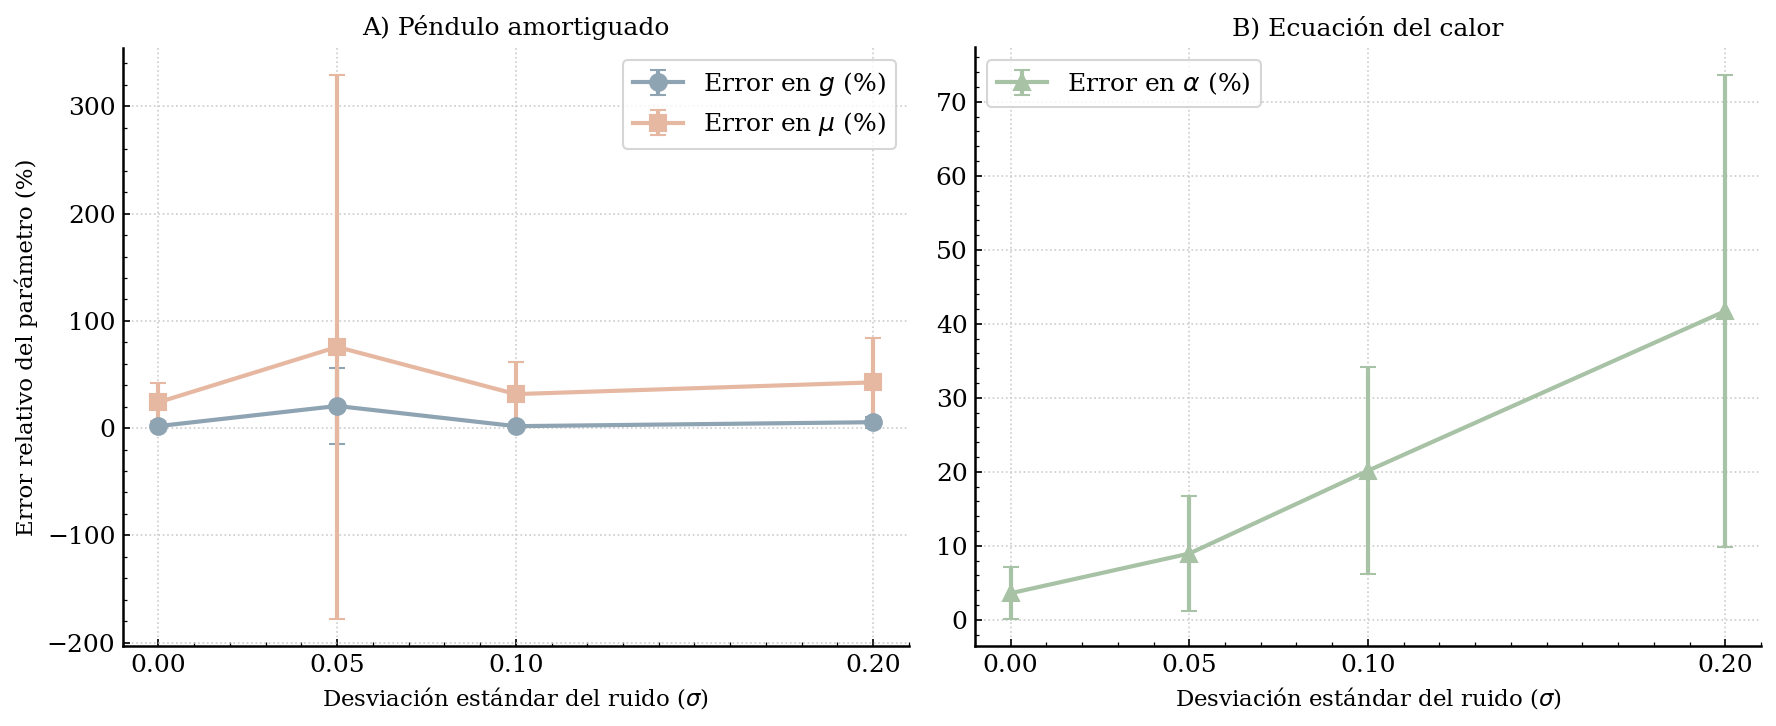

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# ── DEFINICIÓN DE COLORES PASTEL ──────────────────────────────────────────
C_G     = "#8EA4B3"  # Azul pizarra (para gravedad)
C_MU    = "#E6B8A2"  # Melocotón empolvado (para fricción)
C_ALPHA = "#A8C2A6"  # Verde salvia (para difusividad térmica)

# 1. Extraer datos (Péndulo)
noise_p = []
err_g_mean, err_g_std = [], []
err_mu_mean, err_mu_std = [], []

for noise in noise_vals_pendulo:
    mask = ((df_pendulo["noise_std"] == noise) & (df_pendulo["optimizer"] == BASE_PENDULO["optimizer"]))
    grp = df_pendulo[mask]
    if len(grp) > 0:
        noise_p.append(noise)
        err_g_mean.append(grp['error_rel_g'].mean() * 100)
        err_g_std.append(grp['error_rel_g'].std() * 100)
        err_mu_mean.append(grp['error_rel_mu'].mean() * 100)
        err_mu_std.append(grp['error_rel_mu'].std() * 100)

# 2. Extraer datos (Calor)
noise_c = []
err_alpha_mean, err_alpha_std = [], []

for noise in noise_vals_calor:
    mask = ((df_calor["noise_std"] == noise) & (df_calor["alpha_true"] == BASE_CALOR["alpha_true"]) & (df_calor["alpha_init"] == BASE_CALOR["alpha_init"]))
    grp = df_calor[mask]
    if len(grp) > 0:
        noise_c.append(noise)
        err_alpha_mean.append(grp['error_rel_alpha'].mean() * 100)
        err_alpha_std.append(grp['error_rel_alpha'].std() * 100)

# ── Crear Panel 1x2 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# A) Péndulo
ax = axes[0]
ax.errorbar(noise_p, err_g_mean, yerr=err_g_std, fmt='-o', color=C_G, 
            linewidth=2, markersize=8, capsize=4, label="Error en $g$ (%)")
ax.errorbar(noise_p, err_mu_mean, yerr=err_mu_std, fmt='-s', color=C_MU, 
            linewidth=2, markersize=8, capsize=4, label="Error en $\mu$ (%)")

ax.set_xticks(noise_vals_pendulo)
ax.set_xlabel("Desviación estándar del ruido ($\sigma$)", fontsize=11)
ax.set_ylabel("Error relativo del parámetro (%)", fontsize=11)
ax.set_title("A) Péndulo amortiguado", fontsize=12)
ax.legend(frameon=True, edgecolor="#cccccc")
ax.grid(True, linestyle=":", color="#cccccc")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# B) Ecuación del Calor
ax = axes[1]
ax.errorbar(noise_c, err_alpha_mean, yerr=err_alpha_std, fmt='-^', color=C_ALPHA, 
            linewidth=2, markersize=8, capsize=4, label="Error en $\\alpha$ (%)")

ax.set_xticks(noise_vals_calor)
ax.set_xlabel("Desviación estándar del ruido ($\sigma$)", fontsize=11)
ax.set_title("B) Ecuación del calor", fontsize=12)
ax.legend(frameon=True, edgecolor="#cccccc")
ax.grid(True, linestyle=":", color="#cccccc")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig(FIGS_DIR / "eje6_robustez_ruido.png", dpi=300)
plt.show()

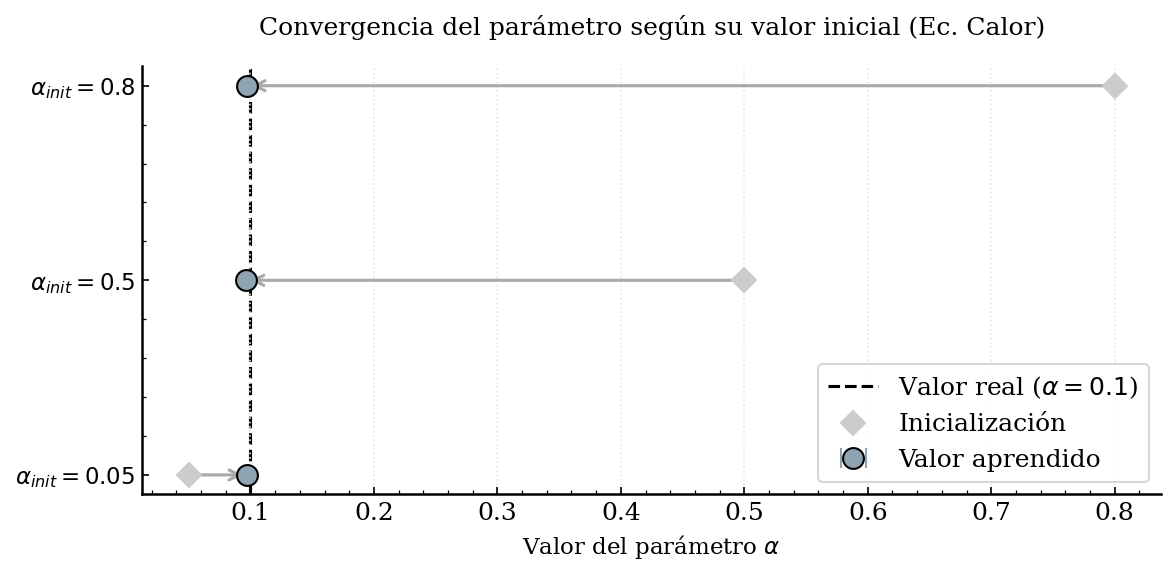

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraer datos de inicialización
init_vals = []
learned_mean = []
learned_std = []

for ai in alpha_init_vals:
    mask = ((df_calor["alpha_init"] == ai) & (df_calor["noise_std"] == 0.0) & (df_calor["alpha_true"] == 0.1))
    grp = df_calor[mask]
    if len(grp) > 0:
        init_vals.append(ai)
        learned_mean.append(grp['alpha_learned'].mean())
        learned_std.append(grp['alpha_learned'].std())

# ── Gráfica de convergencia del parámetro ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

y_pos = np.arange(len(init_vals))

# Dibujar una línea vertical que representa la VERDAD FÍSICA
ax.axvline(0.1, color="black", linestyle="--", linewidth=1.5, zorder=1, label="Valor real ($\\alpha=0.1$)")

# Dibujar desde dónde empezó la red hasta dónde llegó
for i, (ai, mean, std) in enumerate(zip(init_vals, learned_mean, learned_std)):
    # Flecha gris indicando el "viaje" del parámetro desde el inicio hasta el final
    ax.annotate("", xy=(mean, i), xytext=(ai, i),
                arrowprops=dict(arrowstyle="->", color="#aaaaaa", lw=1.5), zorder=2)
    
    # Punto de inicio (semitransparente)
    ax.plot(ai, i, 'D', color="#cccccc", markersize=8, label="Inicialización" if i==0 else "")
    
    # Punto final (lo que aprendió la PINN) con barra de error
    ax.errorbar(mean, i, xerr=std, fmt='o', color="#8EA4B3", markersize=10, 
                markeredgecolor="black", capsize=5, zorder=3, label="Valor aprendido" if i==0 else "")

ax.set_yticks(y_pos)
ax.set_yticklabels([f"$\\alpha_{{init}} = {ai}$" for ai in init_vals], fontsize=11)
ax.set_xlabel("Valor del parámetro $\\alpha$", fontsize=11)
ax.set_title("Convergencia del parámetro según su valor inicial (Ec. Calor)", fontsize=12, pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, axis="x", linestyle=":", color="#e5e5e5")

ax.legend(loc="lower right", frameon=True, edgecolor="#cccccc")

plt.tight_layout()
# plt.savefig(FIGS_DIR / "eje6_calor_inicializacion.png", dpi=300)
plt.show()

In [83]:
# ══════════════════════════════════════════════════════════════════════════
# DATOS PARA SECCIÓN 6.6 — Sistemas cuánticos estacionarios
# ══════════════════════════════════════════════════════════════════════════
import pandas as pd
import json

records_qho = []

for fpath in sorted(RESULTS_DIR.glob("qho/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_qho.append({
        # ── Ruta del archivo (¡CLAVE PARA PODER BORRARLOS LUEGO!) ──
        "filename":            str(fpath), 
        
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "estado_n":            cfg["estado_n"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "use_orthogonality":   cfg["use_orthogonality"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "use_data":            cfg["use_data"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "epsilon_exacto":      res["pinn"]["epsilon_exacto"],
        "epsilon_learned":     res["pinn"]["epsilon_learned"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados FDM ─────────────────────────────────────────
        "error_l2_fdm":        res["fdm"]["error_L2"],
        "time_fdm":            res["fdm"]["time_s"],
        "epsilon_fdm":         res["fdm"]["epsilon_fdm"],
    })

df_qho = pd.DataFrame(records_qho)
print(f"Total experimentos cargados: {len(df_qho)}")

BASE_QHO = {
    "estado_n":            1,
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.5,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "use_orthogonality":   False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "use_data":            True,
}

records_pozo = []

for fpath in sorted(RESULTS_DIR.glob("pozo_infinito/**/*.json")):
    with open(fpath) as f:
        d = json.load(f)

    cfg = d["config"]
    res = d["resultados_finales"]

    records_pozo.append({
        # ── Configuración ──────────────────────────────────────────
        "seed":                cfg["seed"],
        "estado_n":            cfg["estado_n"],
        "epochs":              cfg["epochs"],
        "lr":                  cfg["lr"],
        "num_domain_points":   cfg["num_domain_points"],
        "num_train_points":    cfg["num_train_points"],
        "train_region":        cfg["train_region"],
        "sampler":             cfg["sampler"],
        "use_dynamic_weights": cfg["use_dynamic_weights"],
        "use_orthogonality":   cfg["use_orthogonality"],
        "optimizer":           cfg["optimizer"],
        "hidden_layers":       str(cfg["hidden_layers"]),
        "use_data":            cfg["use_data"],
        # ── Resultados PINN ────────────────────────────────────────
        "error_l2_pinn":       res["pinn"]["error_L2"],
        "time_pinn":           res["pinn"]["time_s"],
        "epsilon_exacto":      res["pinn"]["epsilon_exacto"],
        "epsilon_learned":     res["pinn"]["epsilon_learned"],
        # ── Resultados NN pura ─────────────────────────────────────
        "error_l2_nn":         res["nn"]["error_L2"],
        "time_nn":             res["nn"]["time_s"],
        # ── Resultados FDM ─────────────────────────────────────────
        "error_l2_fdm":        res["fdm"]["error_L2"],
        "time_fdm":            res["fdm"]["time_s"],
        "epsilon_fdm":         res["fdm"]["epsilon_fdm"],
    })

df_pozo = pd.DataFrame(records_pozo)
print(f"Total experimentos cargados: {len(df_pozo)}")

BASE_POZO = {
    "estado_n":            2,
    "num_domain_points":   500,
    "num_train_points":    15,
    "train_region":        0.2,
    "sampler":             "lhs",
    "use_dynamic_weights": False,
    "use_orthogonality":   False,
    "optimizer":           "adam",
    "hidden_layers":       "[32, 32, 32]",
    "lr":                  0.001,
    "use_data":            True,
}

# ── POZO INFINITO — por estado n ──────────────────────────────────────────

print("=" * 120)
print("POZO INFINITO — Resultados por estado cuántico n")
print("=" * 120)

# Filtrar solo configuración base variando estado_n
estados_pozo = [1, 2, 3, 4]

print(f"\n{'n':>3} {'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} {'FDM L2':>12} "
      f"{'ε exacto':>10} {'ε PINN':>10} {'ε std':>8} {'ε FDM':>10} "
      f"{'err ε%':>7} {'N':>4}")
print(f"{'─'*120}")

for n in estados_pozo:
    mask = (
        (df_pozo["estado_n"] == n) &
        (df_pozo["num_domain_points"]   == BASE_POZO["num_domain_points"]) &
        (df_pozo["num_train_points"]    == BASE_POZO["num_train_points"]) &
        (df_pozo["train_region"]        == BASE_POZO["train_region"]) &
        (df_pozo["sampler"]             == BASE_POZO["sampler"]) &
        (df_pozo["use_dynamic_weights"] == BASE_POZO["use_dynamic_weights"]) &
        (df_pozo["use_orthogonality"]   == BASE_POZO["use_orthogonality"]) &
        (df_pozo["optimizer"]           == BASE_POZO["optimizer"]) &
        (df_pozo["hidden_layers"]       == BASE_POZO["hidden_layers"]) &
        (df_pozo["lr"]                  == BASE_POZO["lr"]) &
        (df_pozo["use_data"]            == BASE_POZO["use_data"])
    )
    grp = df_pozo[mask]
    if len(grp) == 0:
        print(f"{n:>3} — sin datos")
        continue
    eps_exact = grp["epsilon_exacto"].iloc[0]
    eps_pinn  = grp["epsilon_learned"].mean()
    eps_std   = grp["epsilon_learned"].std()
    eps_fdm   = grp["epsilon_fdm"].iloc[0]
    err_rel   = abs(eps_pinn - eps_exact) / eps_exact * 100
    print(f"{n:>3} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['error_l2_nn'].mean():>12.4e} {grp['error_l2_fdm'].mean():>12.4e} "
          f"{eps_exact:>10.4f} {eps_pinn:>10.4f} {eps_std:>8.4f} {eps_fdm:>10.4f} "
          f"{err_rel:>7.3f} {len(grp):>4}")

# ── POZO INFINITO — con y sin datos ──────────────────────────────────────

print(f"\n\n{'─'*120}")
print("POZO INFINITO — Con datos vs solo física (estado n=2)")
print(f"{'─'*120}")

for use_data in [True, False]:
    mask = (
        (df_pozo["estado_n"] == 2) &
        (df_pozo["use_data"] == use_data) &
        (df_pozo["num_domain_points"]   == BASE_POZO["num_domain_points"]) &
        (df_pozo["num_train_points"]    == BASE_POZO["num_train_points"]) &
        (df_pozo["train_region"]        == BASE_POZO["train_region"]) &
        (df_pozo["sampler"]             == BASE_POZO["sampler"]) &
        (df_pozo["use_dynamic_weights"] == BASE_POZO["use_dynamic_weights"]) &
        (df_pozo["use_orthogonality"]   == BASE_POZO["use_orthogonality"]) &
        (df_pozo["optimizer"]           == BASE_POZO["optimizer"]) &
        (df_pozo["hidden_layers"]       == BASE_POZO["hidden_layers"]) &
        (df_pozo["lr"]                  == BASE_POZO["lr"])
    )
    grp = df_pozo[mask]
    label = "Con datos" if use_data else "Solo física"
    if len(grp) == 0:
        print(f"{label:<14} — sin datos")
        continue
    eps_pinn = grp["epsilon_learned"].mean()
    eps_std  = grp["epsilon_learned"].std()
    eps_exact = grp["epsilon_exacto"].iloc[0]
    err_rel = abs(eps_pinn - eps_exact) / eps_exact * 100
    print(f"{label:<14} L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| ε={eps_pinn:.4f} ± {eps_std:.4f} | err={err_rel:.3f}% | N={len(grp)}")


# ══════════════════════════════════════════════════════════════════════════
# QHO
# ══════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 120)
print("QHO — Resultados por estado cuántico n")
print("=" * 120)

estados_qho = [0, 1, 2, 3]

print(f"\n{'n':>3} {'PINN L2':>12} {'PINN std':>10} {'NN L2':>12} {'FDM L2':>12} "
      f"{'ε exacto':>10} {'ε PINN':>10} {'ε std':>8} {'ε FDM':>10} "
      f"{'err ε%':>7} {'N':>4}")
print(f"{'─'*120}")

for n in estados_qho:
    mask = (
        (df_qho["estado_n"] == n) &
        (df_qho["num_domain_points"]   == BASE_QHO["num_domain_points"]) &
        (df_qho["num_train_points"]    == BASE_QHO["num_train_points"]) &
        (df_qho["train_region"]        == BASE_QHO["train_region"]) &
        (df_qho["sampler"]             == BASE_QHO["sampler"]) &
        (df_qho["use_dynamic_weights"] == BASE_QHO["use_dynamic_weights"]) &
        (df_qho["use_orthogonality"]   == BASE_QHO["use_orthogonality"]) &
        (df_qho["optimizer"]           == BASE_QHO["optimizer"]) &
        (df_qho["hidden_layers"]       == BASE_QHO["hidden_layers"]) &
        (df_qho["lr"]                  == BASE_QHO["lr"]) &
        (df_qho["use_data"]            == BASE_QHO["use_data"])
    )
    grp = df_qho[mask]
    if len(grp) == 0:
        print(f"{n:>3} — sin datos")
        continue
    eps_exact = grp["epsilon_exacto"].iloc[0]
    eps_pinn  = grp["epsilon_learned"].mean()
    eps_std   = grp["epsilon_learned"].std()
    eps_fdm   = grp["epsilon_fdm"].iloc[0]
    err_rel   = abs(eps_pinn - eps_exact) / eps_exact * 100
    print(f"{n:>3} {grp['error_l2_pinn'].mean():>12.4e} {grp['error_l2_pinn'].std():>10.4e} "
          f"{grp['error_l2_nn'].mean():>12.4e} {grp['error_l2_fdm'].mean():>12.4e} "
          f"{eps_exact:>10.4f} {eps_pinn:>10.4f} {eps_std:>8.4f} {eps_fdm:>10.4f} "
          f"{err_rel:>7.3f} {len(grp):>4}")

# ── QHO — con y sin datos ────────────────────────────────────────────────

print(f"\n\n{'─'*120}")
print("QHO — Con datos vs solo física (estado n=1)")
print(f"{'─'*120}")

for use_data in [True, False]:
    mask = (
        (df_qho["estado_n"] == 1) &
        (df_qho["use_data"] == use_data) &
        (df_qho["num_domain_points"]   == BASE_QHO["num_domain_points"]) &
        (df_qho["num_train_points"]    == BASE_QHO["num_train_points"]) &
        (df_qho["train_region"]        == BASE_QHO["train_region"]) &
        (df_qho["sampler"]             == BASE_QHO["sampler"]) &
        (df_qho["use_dynamic_weights"] == BASE_QHO["use_dynamic_weights"]) &
        (df_qho["use_orthogonality"]   == BASE_QHO["use_orthogonality"]) &
        (df_qho["optimizer"]           == BASE_QHO["optimizer"]) &
        (df_qho["hidden_layers"]       == BASE_QHO["hidden_layers"]) &
        (df_qho["lr"]                  == BASE_QHO["lr"])
    )
    grp = df_qho[mask]
    label = "Con datos" if use_data else "Solo física"
    if len(grp) == 0:
        print(f"{label:<14} — sin datos")
        continue
    eps_pinn = grp["epsilon_learned"].mean()
    eps_std  = grp["epsilon_learned"].std()
    eps_exact = grp["epsilon_exacto"].iloc[0]
    err_rel = abs(eps_pinn - eps_exact) / eps_exact * 100
    print(f"{label:<14} L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| ε={eps_pinn:.4f} ± {eps_std:.4f} | err={err_rel:.3f}% | N={len(grp)}")

# ── QHO — ortogonalidad ──────────────────────────────────────────────────

print(f"\n\n{'─'*120}")
print("QHO — Ortogonalidad (estado n=1)")
print(f"{'─'*120}")

for ortho in [False, True]:
    mask = (
        (df_qho["estado_n"] == 1) &
        (df_qho["use_orthogonality"] == ortho) &
        (df_qho["num_domain_points"]   == BASE_QHO["num_domain_points"]) &
        (df_qho["num_train_points"]    == BASE_QHO["num_train_points"]) &
        (df_qho["train_region"]        == BASE_QHO["train_region"]) &
        (df_qho["sampler"]             == BASE_QHO["sampler"]) &
        (df_qho["use_dynamic_weights"] == BASE_QHO["use_dynamic_weights"]) &
        (df_qho["optimizer"]           == BASE_QHO["optimizer"]) &
        (df_qho["hidden_layers"]       == BASE_QHO["hidden_layers"]) &
        (df_qho["lr"]                  == BASE_QHO["lr"]) &
        (df_qho["use_data"]            == BASE_QHO["use_data"])
    )
    grp = df_qho[mask]
    label = "Con ortogonalidad" if ortho else "Sin ortogonalidad"
    if len(grp) == 0:
        print(f"{label:<20} — sin datos")
        continue
    eps_pinn = grp["epsilon_learned"].mean()
    eps_std  = grp["epsilon_learned"].std()
    eps_exact = grp["epsilon_exacto"].iloc[0]
    err_rel = abs(eps_pinn - eps_exact) / eps_exact * 100
    print(f"{label:<20} L2={grp['error_l2_pinn'].mean():.4e} ± {grp['error_l2_pinn'].std():.4e} "
          f"| ε={eps_pinn:.4f} ± {eps_std:.4f} | err={err_rel:.3f}% | N={len(grp)}")

Total experimentos cargados: 250
Total experimentos cargados: 230
POZO INFINITO — Resultados por estado cuántico n

  n      PINN L2   PINN std        NN L2       FDM L2   ε exacto     ε PINN    ε std      ε FDM  err ε%    N
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1   6.8948e-05 5.6808e-05   7.7677e-01   2.0760e-03     4.9348     4.9348   0.0001     4.9151   0.000   10
  2   3.9263e-03 5.0726e-03   1.9231e+00   3.7735e-03    19.7392    19.7392   0.0001    19.6603   0.000   10
  3   1.2222e-03 1.8397e-03   1.0856e+00   5.5486e-03    44.4132    44.4133   0.0002    44.2356   0.000   10
  4   1.7282e-03 2.5613e-03   9.1472e-01   7.3454e-03    78.9568    78.9487   0.0120    78.6406   0.010   10


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
POZO INFINITO — Con datos vs solo física (estado n=2)
─────────────────────────────────────────